In [56]:
pip install geopandas plotly

Note: you may need to restart the kernel to use updated packages.


In [57]:
#import modules
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import matplotlib.animation as animation
import seaborn as sns
import geopandas as gpd
import plotly
import plotly.express as px

import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "nbformat>=4.2.0"])

0

In [58]:
#load data
zillow_df = pd.read_csv('../data/processed/zillow_df.csv')

In [59]:
zillow_df.head()

,pop_rank,city,state,month,year,mean_sales_price,number_of_sales,home_value,market_heat_index,value_surplus
0,83,"Akron, OH",OH,2,2008,111182.75,398.0,124307.869610,NaN,-13125.119610
1,83,"Akron, OH",OH,3,2008,117496.40,403.0,124112.725495,NaN,-6616.325495
2,83,"Akron, OH",OH,4,2008,116325.50,480.0,124067.896104,NaN,-7742.396104
3,83,"Akron, OH",OH,5,2008,140846.00,478.0,124246.821831,NaN,16599.178169
4,83,"Akron, OH",OH,6,2008,137244.50,603.0,124224.500972,NaN,13019.999028


In [60]:
zillow_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27906 entries, 0 to 27905
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pop_rank           27906 non-null  int64  
 1   city               27906 non-null  str    
 2   state              27906 non-null  str    
 3   month              27906 non-null  int64  
 4   year               27906 non-null  int64  
 5   mean_sales_price   27906 non-null  float64
 6   number_of_sales    18325 non-null  float64
 7   home_value         27906 non-null  float64
 8   market_heat_index  11881 non-null  float64
 9   value_surplus      27906 non-null  float64
dtypes: float64(5), int64(3), str(2)
memory usage: 2.1 MB


In [61]:
zillow_df.describe().round(2)

,pop_rank,month,year,mean_sales_price,number_of_sales,home_value,market_heat_index,value_surplus
count,27906.00,27906.00,27906.00,27906.00,18325.00,27906.00,11881.00,27906.00
mean,75.58,6.50,2016.18,294513.53,2512.24,249436.29,63.53,45077.24
std,48.13,3.45,4.90,202507.82,2670.13,163156.75,19.66,58227.68
min,1.00,1.00,2008.00,67682.00,72.00,44533.95,10.00,-133828.19
25%,36.00,3.00,2012.00,171490.68,839.00,146886.26,50.00,14565.49
50%,71.00,6.00,2016.00,232129.88,1474.00,200378.50,61.00,31432.62
75%,109.00,9.00,2020.00,337199.69,3100.00,289127.84,74.00,55355.61
max,242.00,12.00,2025.00,2100471.50,23983.00,1744103.89,235.00,898207.58


In [62]:
#create variable for features
stats_cat = ['mean_sales_price', 'number_of_sales', 'home_value', 'market_heat_index', 'value_surplus', 'pop_rank']

In [63]:
def mean_func(col, *args):
    """get mean values for feature categories"""
    valid_stats_cat = [c for c in stats_cat if c in zillow_df.columns]
    return zillow_df.groupby([col, *args])[valid_stats_cat].mean().sort_values(
        'mean_sales_price', ascending=False
    ).round(2)

def median_func(col, *args):
    """get median values for feature categories"""
    valid_stats_cat = [c for c in stats_cat if c in zillow_df.columns]
    return zillow_df.groupby([col, *args])[valid_stats_cat].median().sort_values(
        'mean_sales_price', ascending=False
        ).round(2)

In [64]:
#analyze data by state
# ensure a consistent 'state' column exists (maps from 'StateName' if present)
if 'state' not in zillow_df.columns and 'StateName' in zillow_df.columns:
    zillow_df['state'] = zillow_df['StateName']

state_means = mean_func('state', 'year')
state_means = state_means.reset_index()
state_means

,state,year,mean_sales_price,number_of_sales,home_value,market_heat_index,value_surplus,pop_rank
0,HI,2025,1123507.00,561.00,1046223.07,62.00,77283.93,55.00
1,HI,2024,1097341.24,672.58,1040668.87,47.67,56672.37,55.00
2,HI,2022,1096830.55,930.58,1053856.47,73.33,42974.07,55.00
3,HI,2023,1087527.75,667.42,1032767.70,59.00,54760.05,55.00
4,HI,2021,1003634.80,1145.83,903909.06,85.75,99725.74,55.00
...,...,...,...,...,...,...,...,...
733,MI,2008,108917.44,3225.95,114913.46,NaN,-5996.02,77.25
734,MI,2012,107678.58,3683.83,86798.28,NaN,20880.29,77.25
735,MI,2010,100665.20,3168.00,92004.17,NaN,8661.03,77.25
736,MI,2011,99921.90,3266.08,85282.66,NaN,14639.24,77.25


In [65]:
#analyze median by state
state_medians = median_func('state', 'year')
state_medians = state_medians.reset_index()
state_medians

,state,year,mean_sales_price,number_of_sales,home_value,market_heat_index,value_surplus,pop_rank
0,HI,2025,1123507.00,561.0,1046223.07,62.0,77283.93,55.0
1,HI,2023,1105942.38,685.0,1032516.46,60.0,72090.25,55.0
2,HI,2022,1096793.75,929.0,1061969.34,71.0,51801.00,55.0
3,HI,2024,1088757.82,671.5,1044232.72,47.0,43874.08,55.0
4,HI,2021,989423.08,1191.5,916538.21,86.5,93008.02,55.0
...,...,...,...,...,...,...,...,...
733,OH,2009,107022.65,1132.0,118396.20,NaN,-3528.02,83.0
734,MI,2012,105831.00,3128.5,90566.41,NaN,19301.22,80.0
735,MI,2010,103038.62,2817.0,93338.43,NaN,10714.58,80.0
736,MI,2011,100476.50,2793.5,88898.34,NaN,13643.42,80.0


In [66]:
#difference in means/medians
valid_stats_cat = [c for c in stats_cat if c in state_means.columns and c in state_medians.columns]
diff_state_mean_median = state_means[valid_stats_cat] - state_medians[valid_stats_cat]
diff_state_mean_median.sort_values('mean_sales_price', ascending=False)

,mean_sales_price,number_of_sales,home_value,market_heat_index,value_surplus,pop_rank
9,102875.09,-208.64,201284.57,23.86,-98409.48,-12.14
6,101870.02,620.90,-38777.22,19.86,140300.08,4.36
7,88899.85,1770.84,77214.23,NaN,5023.46,4.36
8,84369.37,-138.50,18028.92,14.33,68097.61,0.00
10,69889.44,2565.48,-116475.33,NaN,182882.04,4.36
...,...,...,...,...,...,...
736,-554.60,472.58,-3615.68,NaN,995.82,-2.75
3,-1230.07,-4.08,-11465.02,12.00,10885.97,0.00
735,-2373.42,351.00,-1334.26,NaN,-2053.55,-2.75
737,-3169.87,499.00,-3879.85,NaN,800.27,-2.75


Median will be better to use as there is a significant difference in most states between mean and median, showing outliers skewed mean

First, we'll look into the current prices for each state

In [67]:
#filter for current prices
state_2025 = state_means[state_means['year'] == 2025]
state_2025

,state,year,mean_sales_price,number_of_sales,home_value,market_heat_index,value_surplus,pop_rank
0,HI,2025,1123507.00,561.00,1046223.07,62.00,77283.93,55.00
6,CA,2025,848024.07,1487.90,753619.68,71.86,94404.39,59.36
14,NV,2025,719671.50,2136.00,500593.68,53.00,219077.82,71.50
18,MA,2025,684438.00,1157.67,574118.58,73.00,110319.42,88.75
22,WA,2025,665142.50,2242.00,588200.54,67.50,76941.96,57.50
27,RI,2025,646531.00,923.00,491692.13,73.00,154838.87,39.00
31,OR,2025,634532.00,1581.00,554917.60,65.00,79614.40,25.00
54,UT,2025,588137.50,571.00,552992.90,60.00,35144.60,70.00
56,CT,2025,587105.67,673.33,493378.43,83.00,93727.23,59.00
59,CO,2025,574876.75,1078.67,531813.33,54.50,43063.42,103.00


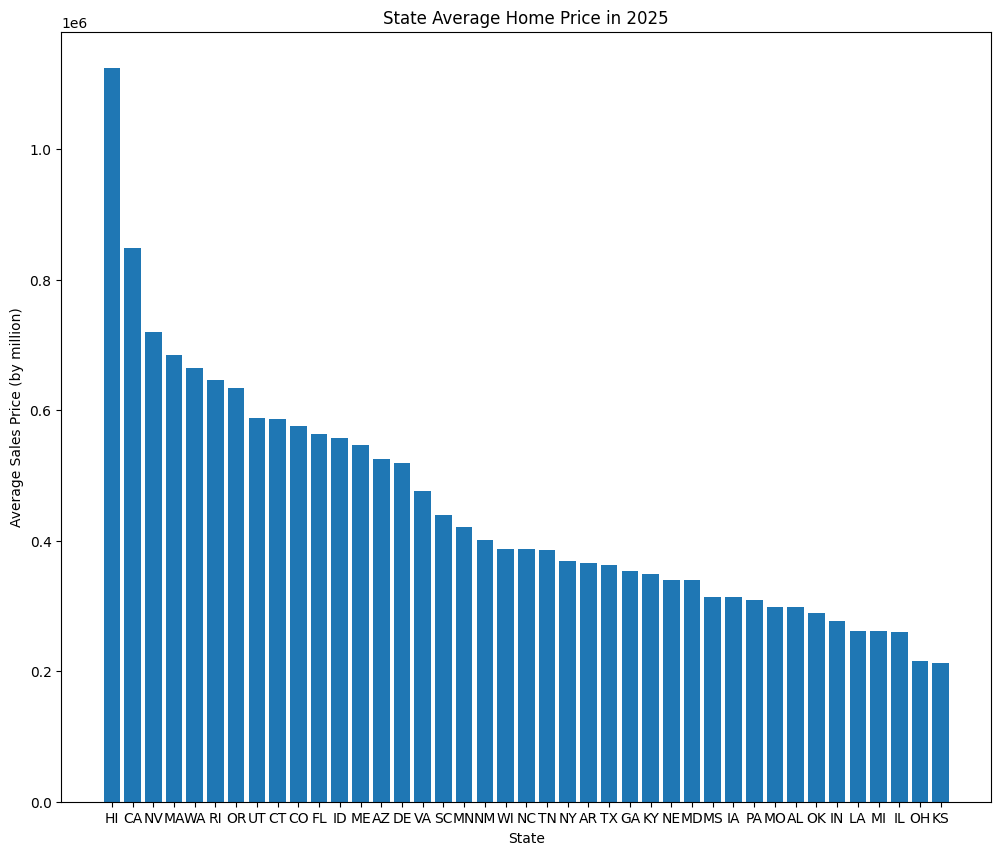

In [68]:
#filter for current prices
state_2025 = state_means[state_means['year'] == 2025]

#plot sales price
fig, ax = plt.subplots(figsize=(12, 10))
plt.bar(state_2025.state, state_2025.mean_sales_price)
plt.xlabel('State')
plt.ylabel('Average Sales Price (by million)')
plt.title('State Average Home Price in 2025')
plt.show()

We can see that Hawaii has the highest home prices in 2025 at 1,123,507 USD. California was the only other state over 800K at 848,024 USD.

Now we'll see the average over the entire scope of our data

In [69]:
state_means_total = state_means.groupby('state').mean().sort_values('mean_sales_price', ascending=False).round(2)
state_means_total = state_means_total.reset_index()
state_means_total

,state,year,mean_sales_price,number_of_sales,home_value,market_heat_index,value_surplus,pop_rank
0,HI,2016.5,798145.34,773.13,762123.23,61.47,36022.10,55.00
1,CA,2016.5,560571.78,2694.06,480650.49,74.06,79921.28,59.36
2,CT,2016.5,455678.14,998.60,345106.52,74.12,110571.62,59.00
3,MA,2016.5,430120.91,1876.81,368001.71,73.53,62119.20,87.81
4,WA,2016.5,419479.44,4274.73,362245.53,75.21,57233.92,57.50
5,OR,2016.5,419236.90,2717.12,374759.27,71.71,44477.62,25.00
6,CO,2016.5,380901.81,1872.65,346654.35,66.73,34247.46,103.00
7,NV,2016.5,377478.73,3570.45,305333.15,60.72,72145.58,71.50
8,ME,2016.5,376310.79,NaN,313354.61,74.19,62956.17,105.00
9,UT,2016.5,374127.99,887.91,341054.56,67.32,33073.43,70.00


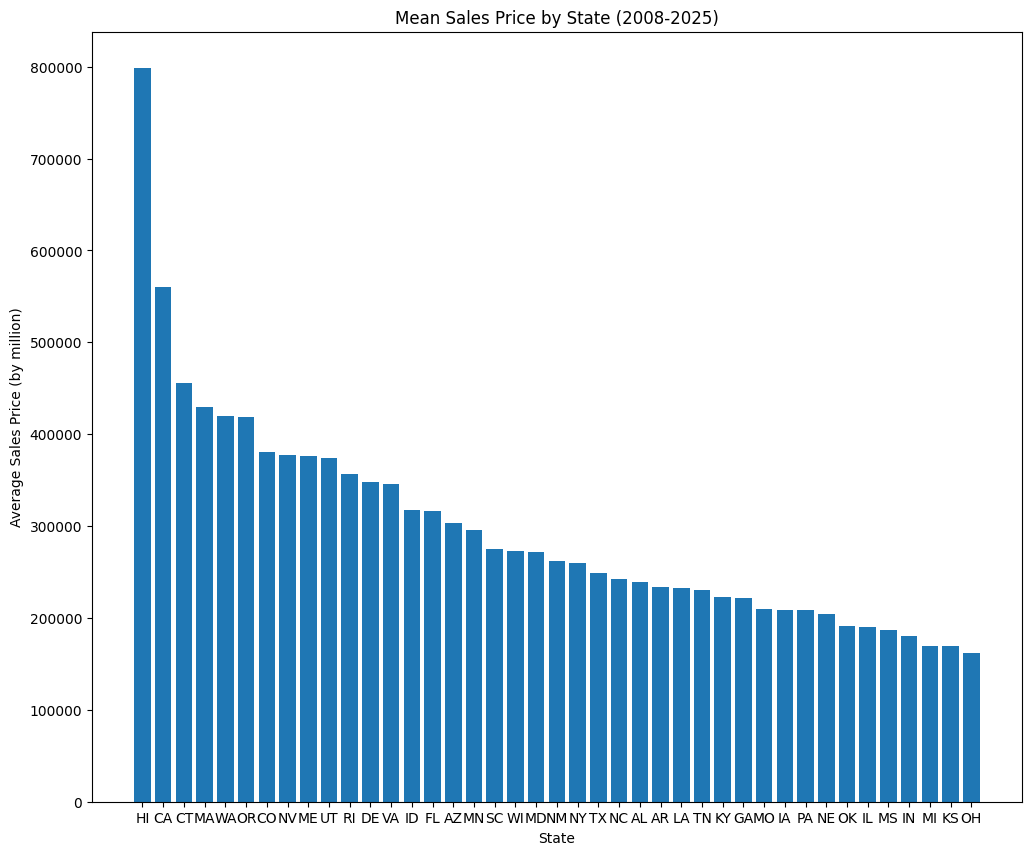

In [70]:
#plot data by state means
fig, ax = plt.subplots(figsize=(12, 10))
plt.bar(state_means_total.state, state_means_total.mean_sales_price)
plt.xlabel('State')
plt.ylabel('Average Sales Price (by million)')
plt.title('Mean Sales Price by State (2008-2025)')
plt.show()

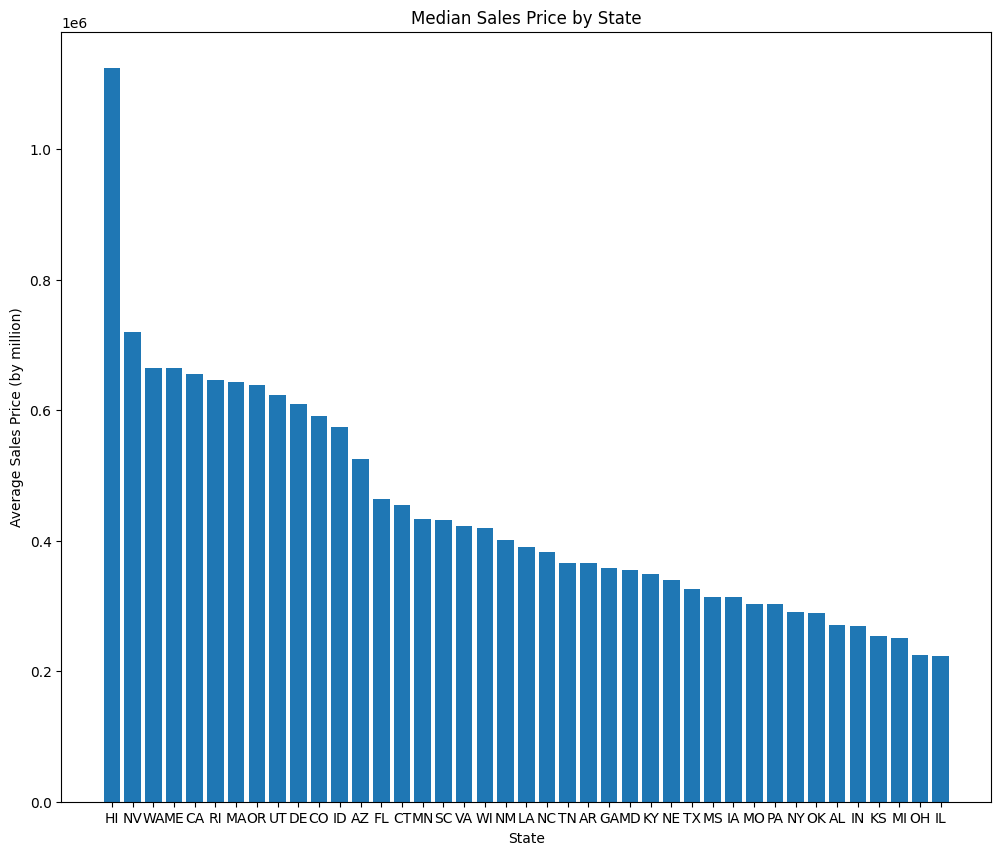

In [71]:
#plot data by state median price
fig, ax = plt.subplots(figsize=(12, 10))
plt.bar(state_medians.state, state_medians.mean_sales_price)
plt.xlabel('State')
plt.ylabel('Average Sales Price (by million)')
plt.title('Median Sales Price by State')
plt.show()

Hawaii by far has the highest mean/median sales price. Other states are all at around 750K or lower while Hawaii is over 1M. California seems to decrease most from mean to median

In [72]:
#analyze data by year
year_mean = mean_func('year')
year_mean = year_mean.sort_values('year', ascending=False)
year_mean

,mean_sales_price,number_of_sales,home_value,market_heat_index,value_surplus,pop_rank
year,,,,,,
2025,461108.46,1551.01,391514.89,56.01,69593.57,77.48
2024,463510.19,2108.36,386406.66,58.94,77103.53,77.48
2023,438896.68,2112.46,371409.54,65.20,67487.14,77.48
2022,429329.65,2794.72,365981.27,70.10,63348.38,77.48
2021,391022.98,3492.19,318623.02,79.62,72399.96,77.48
2020,334694.80,2938.86,275304.76,70.02,59390.05,77.48
2019,302456.71,2817.74,260287.41,52.48,42169.31,77.48
2018,294243.32,2846.73,251077.85,48.79,43165.46,76.12
2017,276543.86,2941.44,235212.60,NaN,41331.26,75.07


In [73]:
#analyze data by year
year_median = median_func('year')
year_median = year_median.sort_values('year', ascending=False)
year_median

,mean_sales_price,number_of_sales,home_value,market_heat_index,value_surplus,pop_rank
year,,,,,,
2025,384251.00,942.0,343684.38,53.5,52635.06,72.5
2024,389794.98,1304.0,338030.71,56.0,57370.89,72.5
2023,367198.00,1296.5,321173.79,63.0,48890.49,72.5
2022,352211.58,1684.0,307538.66,67.0,46101.95,72.5
2021,319498.75,2084.0,267536.68,76.0,52750.42,72.5
2020,273379.62,1826.5,234786.17,68.5,44088.08,72.5
2019,247379.30,1701.0,222277.42,53.0,32994.57,72.5
2018,237773.00,1696.5,212428.95,48.0,32850.17,72.0
2017,224393.72,1726.0,199482.18,NaN,31315.94,71.0


In [74]:
zillow_df['year'].value_counts()

year
2019    1680
2020    1680
2021    1680
2022    1680
2023    1680
2024    1680
2018    1661
2017    1636
2013    1632
2014    1632
2015    1632
2016    1632
2012    1631
2011    1608
2010    1592
2009    1570
2008    1460
2025     140
Name: count, dtype: int64

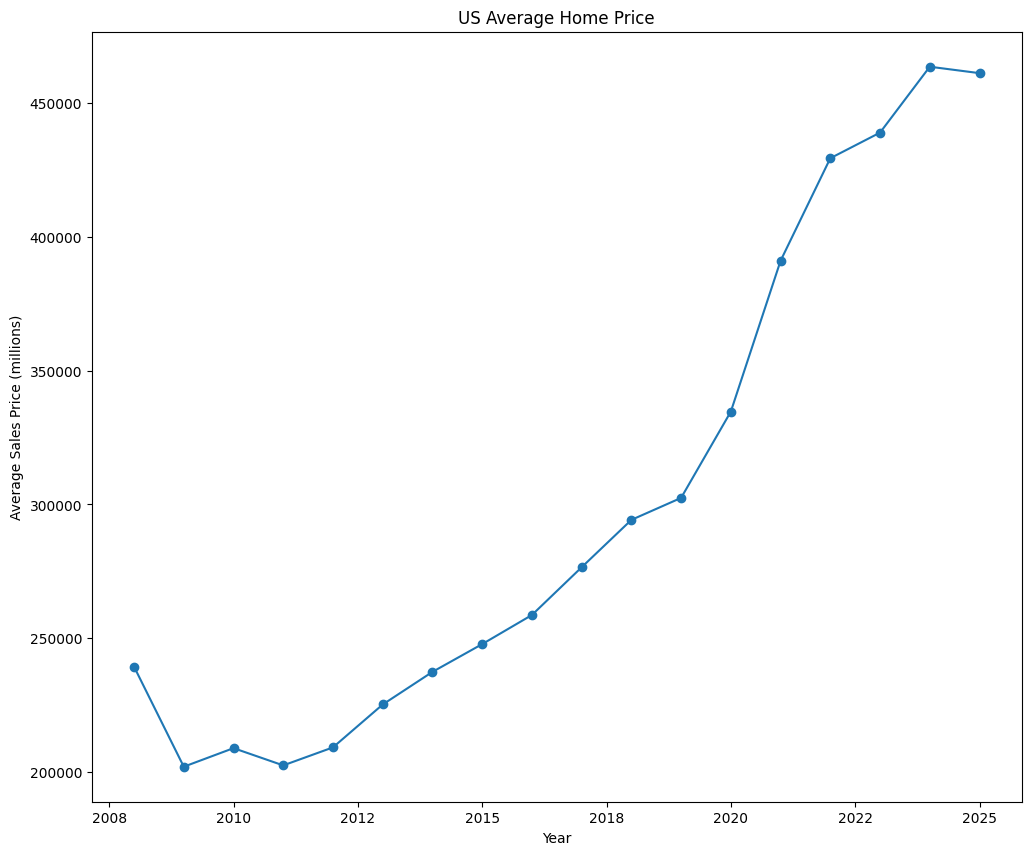

In [75]:
#lineplot of year mean data
fig, ax = plt.subplots(figsize=(12, 10))
plt.plot(year_mean.index, year_mean.mean_sales_price, marker='o')
ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
plt.xlabel('Year')
plt.ylabel('Average Sales Price (millions)')
plt.title('US Average Home Price')
plt.show()

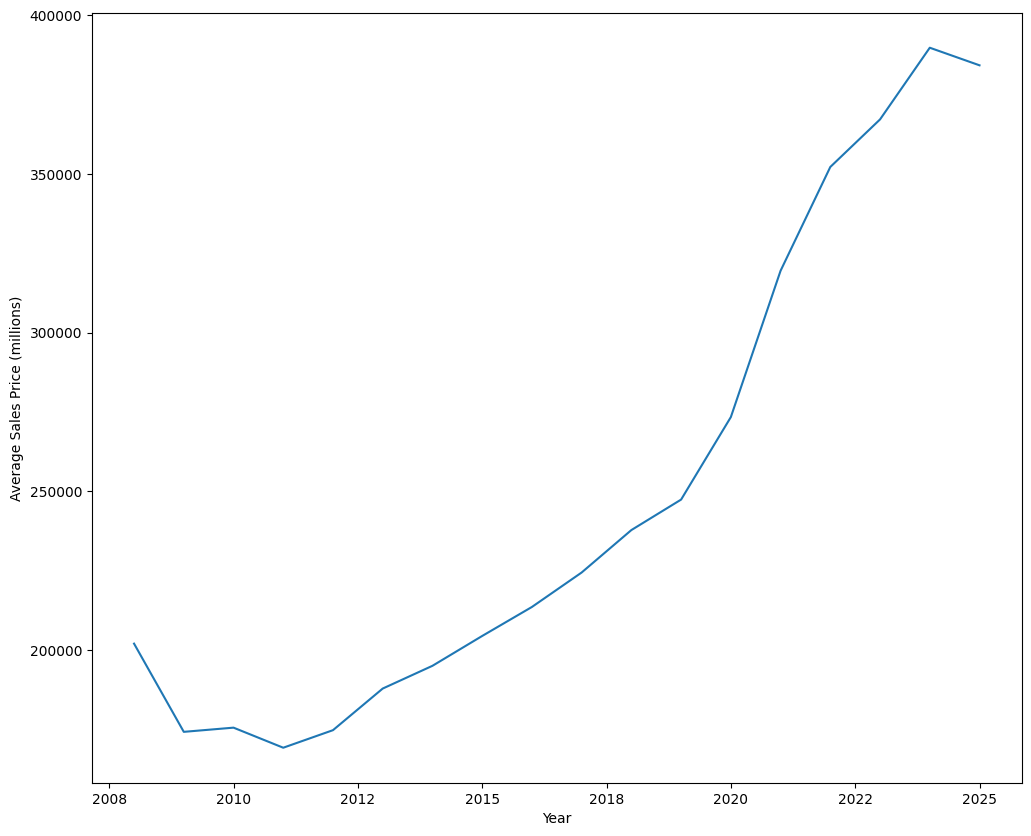

In [76]:
#lineplot of year median data
fig, ax = plt.subplots(figsize=(12, 10))
plt.plot(year_median.index, year_median.mean_sales_price)
ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
plt.xlabel('Year')
plt.ylabel('Average Sales Price (millions)')
plt.show()

As expected, price increases steeply by year. After the 2008 recession we see a small dip for the next 3-4 years before increasing moderatly until 2020. After covid in 2020, the increase is steeper leading up to 2024 

In [77]:
#analyze monthly data
month_mean = mean_func('month')
month_mean = month_mean.sort_values('month')
month_mean

,mean_sales_price,number_of_sales,home_value,market_heat_index,value_surplus,pop_rank
month,,,,,,
1,287576.18,1826.33,253418.10,64.36,34158.09,75.61
2,275373.90,1870.42,244219.90,69.79,31154.00,75.72
3,285393.30,2460.65,245361.04,70.60,40032.26,75.72
4,293005.80,2560.61,246627.91,70.35,46377.90,75.72
5,300857.69,2815.87,247836.60,67.79,53021.09,75.72
6,308603.04,3064.36,248885.81,65.09,59717.24,75.72
7,306750.55,2910.82,249611.72,63.27,57138.83,75.74
8,302256.70,2905.11,250429.49,61.17,51827.21,75.33
9,296025.57,2576.81,250923.41,58.08,45102.16,75.36


In [78]:
month_median = median_func('month')
month_median = month_median.sort_values('month')
month_median

,mean_sales_price,number_of_sales,home_value,market_heat_index,value_surplus,pop_rank
month,,,,,,
1,224095.80,1044.5,202249.16,60.0,21580.69,71.0
2,215254.75,1088.0,197237.57,66.0,18885.38,71.0
3,222319.00,1450.5,198078.09,68.0,25087.34,71.0
4,229386.80,1528.0,198871.35,69.0,29990.17,71.0
5,237080.75,1692.5,199379.69,67.0,36236.88,71.0
6,244619.75,1810.5,200076.16,64.0,43228.82,71.0
7,244115.00,1709.0,200266.29,61.0,43010.46,71.0
8,241057.75,1690.0,201461.15,59.0,38300.77,71.0
9,233321.75,1490.0,201781.38,56.0,32624.86,71.0


In [79]:
zillow_df['month'].value_counts()

month
7     2330
2     2329
3     2329
4     2329
5     2329
6     2329
1     2327
11    2323
12    2323
10    2322
9     2319
8     2317
Name: count, dtype: int64

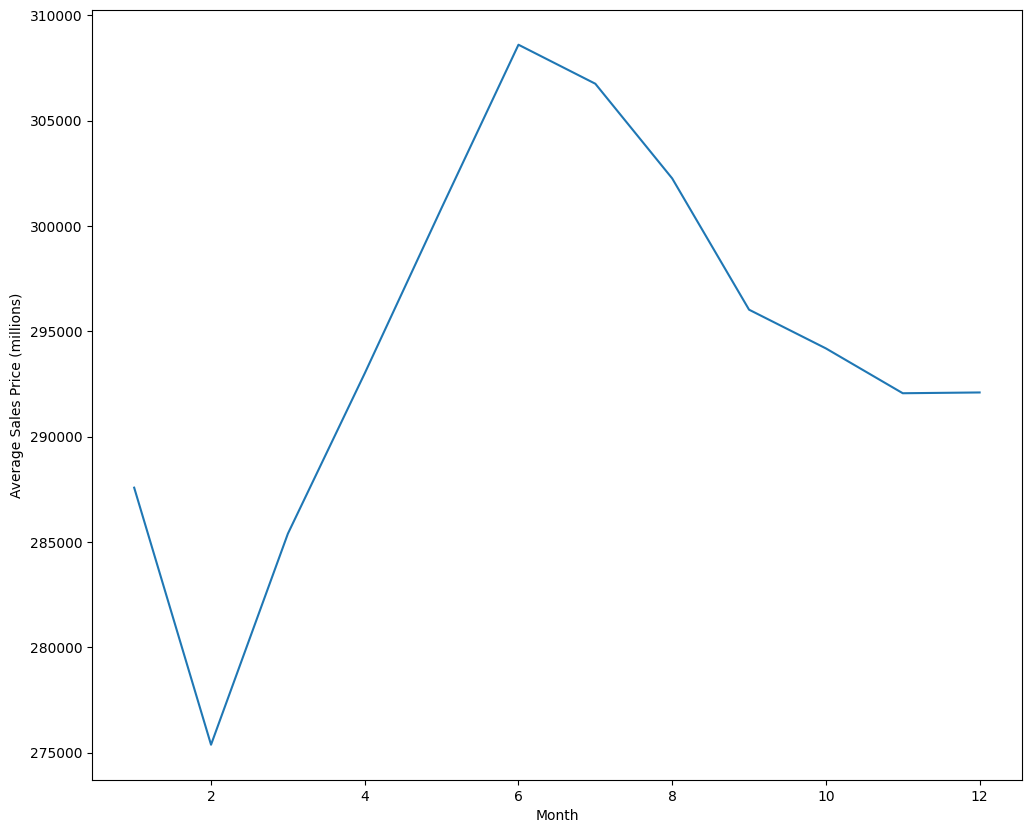

In [80]:
#lineplot of month mean data
fig, ax = plt.subplots(figsize=(12, 10))
plt.plot(month_mean.index, month_mean.mean_sales_price)
plt.xlabel('Month')
plt.ylabel('Average Sales Price (millions)')
plt.show()

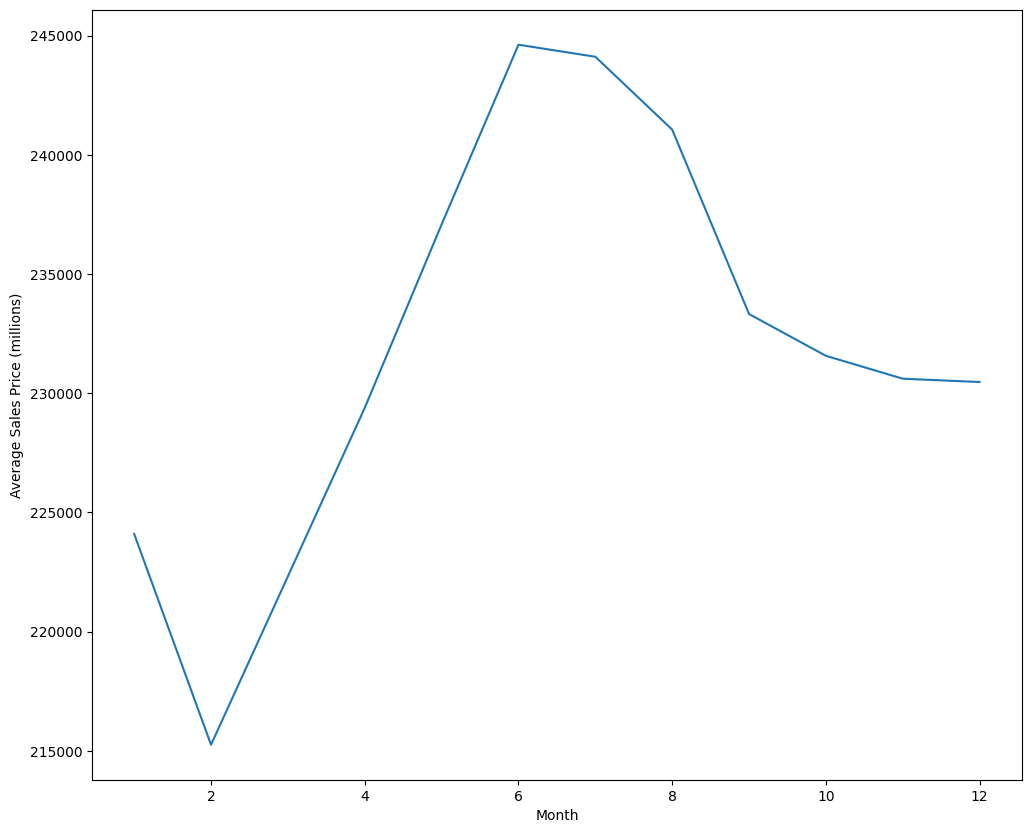

In [81]:
#lineplot of month median data
fig, ax = plt.subplots(figsize=(12, 10))
plt.plot(month_median.index, month_median.mean_sales_price)
plt.xlabel('Month')
plt.ylabel('Average Sales Price (millions)')
plt.show()

January data is slightly skewed because it is the only month that also has 2025 data. Interestingly the data peaks around June of each year and levels off by December. The increases are very small for house prices (less than 10% through highest and lowest peaks). Is this related to number of sales per month?

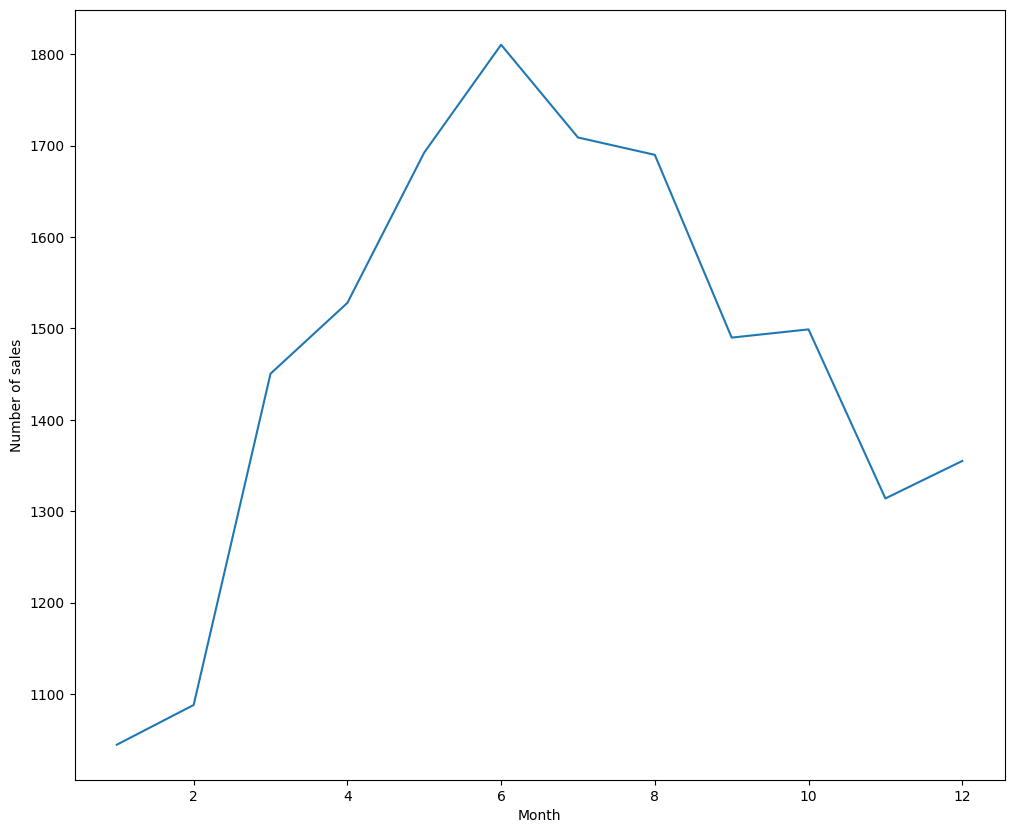

In [82]:
#number of sales by month
fig, ax = plt.subplots(figsize=(12, 10))
plt.plot(month_median.index, month_median.number_of_sales)
plt.xlabel('Month')
plt.ylabel('Number of sales')
plt.show()

We can see that the number of sales per month increases around 80% between January and June. This chart closely resembles the mean sales price meaning the 8-10% jump from Feb to June could be a result of larger sample size

In [83]:
#create bins for population rank data
# ensure a pop_rank column exists (use SizeRank if available)
if 'pop_rank' not in zillow_df.columns:
    if 'SizeRank' in zillow_df.columns:
        zillow_df['pop_rank'] = zillow_df['SizeRank']
    else:
        zillow_df['pop_rank'] = np.nan

# build bins using the pop_rank max (fallback to 300 if max is small or NaN)
max_rank = int(zillow_df['pop_rank'].max()) if zillow_df['pop_rank'].notna().any() else 300
if max_rank <= 200:
    max_rank = 300

pr_bins = [0, 25, 50, 75, 100, 125, 150, 175, 200, max_rank]
pr_labels = ['25', '50', '75', '100', '125', '150', '175', '200', '300']

In [84]:
#sort by size rank
pop_rank_mean = mean_func('pop_rank')
pop_rank_mean['binned'] = pd.cut(pop_rank_mean.index, pr_bins, labels=pr_labels)
pop_rank_mean = pop_rank_mean.groupby(['binned']).mean().round(2).sort_values('binned')
pop_rank_mean

,mean_sales_price,number_of_sales,home_value,market_heat_index,value_surplus,pop_rank
binned,,,,,,
25,402742.84,5654.05,333645.68,67.44,69097.17,13.00
50,300945.41,1978.76,258845.60,68.75,42099.81,37.83
75,303072.47,985.59,253552.60,65.17,49519.87,62.54
100,232826.01,877.57,206020.30,63.15,26805.71,88.41
125,255204.45,NaN,225864.44,60.93,29340.01,111.48
150,249538.96,NaN,192904.36,54.52,56634.60,135.69
175,221329.81,494.58,198116.58,59.02,23213.24,159.75
200,438156.52,NaN,258506.00,51.18,179650.52,176.00
300,405005.04,NaN,316940.45,53.01,88064.59,215.67


In [85]:
pop_rank_median = median_func('pop_rank')
pop_rank_median['binned'] = pd.cut(pop_rank_median.index, pr_bins, labels=pr_labels)
pop_rank_median = pop_rank_median.groupby(['binned']).mean().round(2).sort_values('binned')
pop_rank_median

,mean_sales_price,number_of_sales,home_value,market_heat_index,value_surplus,pop_rank
binned,,,,,,
25,371239.55,5497.54,307611.04,65.52,65617.10,13.00
50,274124.47,1944.00,233982.76,67.13,39437.54,37.83
75,274517.93,960.48,231296.28,63.71,44656.81,62.54
100,208272.48,830.79,182110.37,61.45,24417.98,88.41
125,229925.47,NaN,206081.93,59.05,25639.98,111.48
150,234640.77,NaN,175214.75,52.15,52831.83,135.69
175,202257.88,488.00,181630.19,56.88,19955.51,159.75
200,370492.00,NaN,227148.94,49.00,147575.53,176.00
300,374795.00,NaN,289157.14,49.67,76121.64,215.67


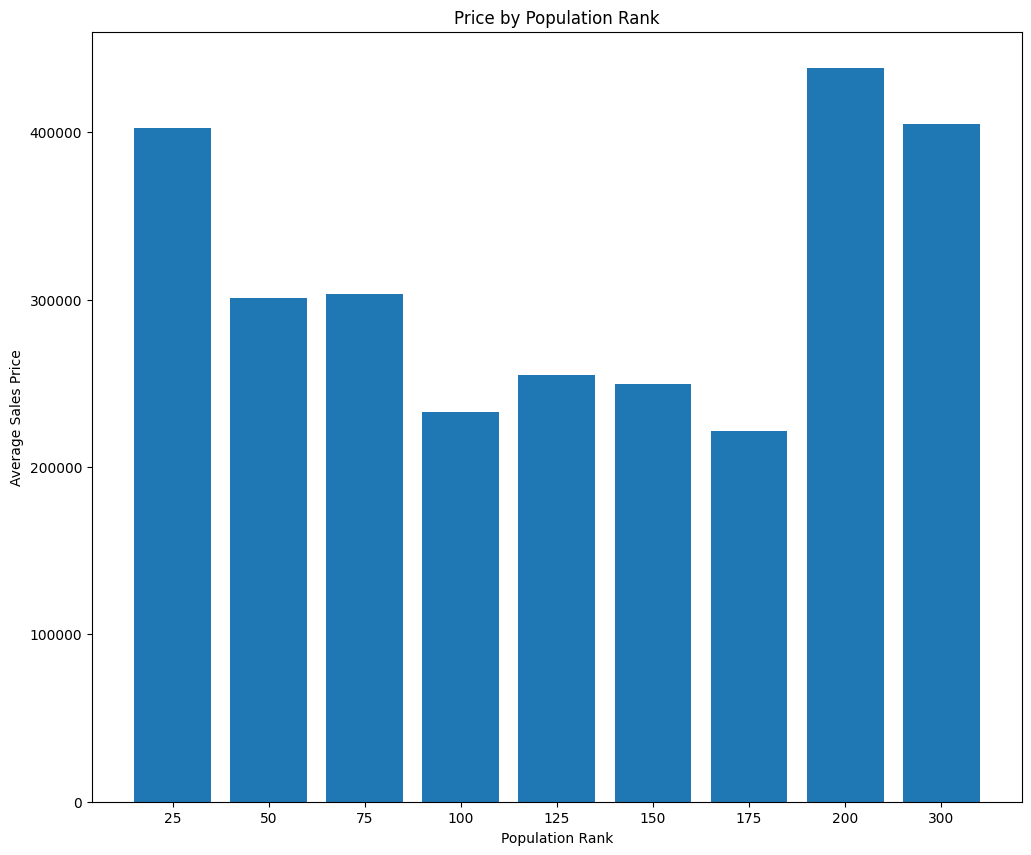

In [86]:
#chart for size rank by mean_sales_price
fig, ax = plt.subplots(figsize=(12, 10))
plt.bar(pop_rank_mean.index, pop_rank_mean.mean_sales_price)
plt.xlabel('Population Rank')
plt.ylabel('Average Sales Price')
plt.title('Price by Population Rank')
plt.show()

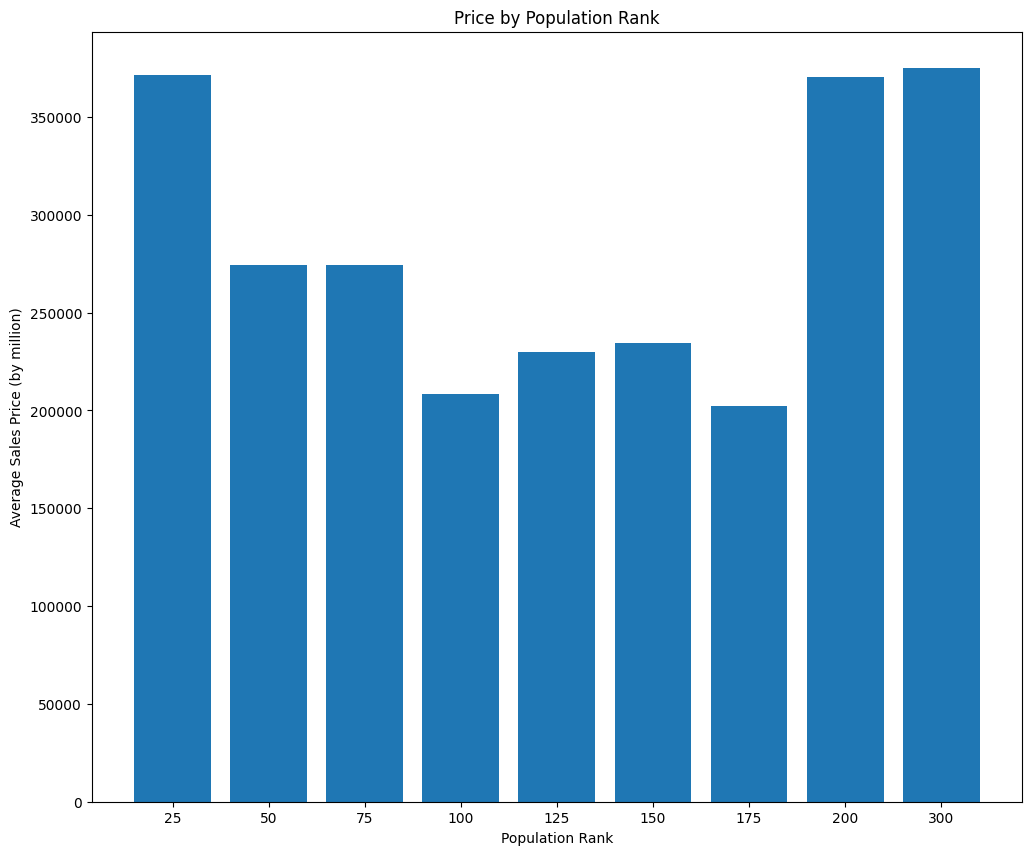

In [87]:
fig, ax = plt.subplots(figsize=(12, 10))
plt.bar(pop_rank_median.index, pop_rank_median.mean_sales_price)
plt.xlabel('Population Rank')
plt.ylabel('Average Sales Price (by million)')
plt.title('Price by Population Rank')
plt.show()

These charts are being affected heavily by outliers in smaller population rank cities.

In [88]:
#look at outliers in 250+ population rank
pop_200 = zillow_df[zillow_df['pop_rank'] > 200]
pop_200

,pop_rank,city,state,month,year,mean_sales_price,number_of_sales,home_value,market_heat_index,value_surplus
1836,202,"Barnstable Town, MA",MA,2,2008,391760.00,NaN,409014.645710,NaN,-17254.645710
1837,202,"Barnstable Town, MA",MA,3,2008,391760.00,NaN,409016.490526,NaN,-17256.490526
1838,202,"Barnstable Town, MA",MA,4,2008,391760.00,NaN,407852.345781,NaN,-16092.345781
1839,202,"Barnstable Town, MA",MA,5,2008,391760.00,NaN,405367.149787,NaN,-13607.149787
1840,202,"Barnstable Town, MA",MA,6,2008,391760.00,NaN,403645.319477,NaN,-11885.319477
...,...,...,...,...,...,...,...,...,...,...
17217,242,"Panama City, FL",FL,9,2024,374456.25,NaN,316787.427945,28.0,57668.822055
17218,242,"Panama City, FL",FL,10,2024,407064.00,NaN,315957.827915,27.0,91106.172085
17219,242,"Panama City, FL",FL,11,2024,381162.20,NaN,315282.295717,27.0,65879.904283
17220,242,"Panama City, FL",FL,12,2024,389702.75,NaN,315400.209414,28.0,74302.540586


In [89]:
pop_200.describe()

,pop_rank,month,year,mean_sales_price,number_of_sales,home_value,market_heat_index,value_surplus
count,465.000000,465.000000,465.000000,4.650000e+02,0.0,465.000000,245.000000,465.000000
mean,209.367742,6.432258,2017.230108,4.245218e+05,NaN,333152.099346,53.314286,91369.683987
std,15.010350,3.441042,4.795467,1.980091e+05,NaN,148679.338230,20.779956,69108.622316
min,202.000000,1.000000,2008.000000,1.272062e+05,NaN,150819.217818,10.000000,-34740.304510
25%,202.000000,3.000000,2013.000000,2.610380e+05,NaN,203453.709804,38.000000,41754.283025
50%,203.000000,6.000000,2018.000000,4.109788e+05,NaN,324657.297270,50.000000,80047.427293
75%,203.000000,9.000000,2021.000000,4.940422e+05,NaN,386731.091738,67.000000,120609.183382
max,242.000000,12.000000,2025.000000,1.086138e+06,NaN,761305.321675,117.000000,326080.603134


In [90]:
pop_200.sort_values('mean_sales_price', ascending=False)

,pop_rank,city,state,month,year,mean_sales_price,number_of_sales,home_value,market_heat_index,value_surplus
2029,202,"Barnstable Town, MA",MA,9,2024,1086138.50,NaN,760057.896866,52.0,326080.603134
2033,202,"Barnstable Town, MA",MA,1,2025,1078110.00,NaN,759004.578839,50.0,319105.421161
2030,202,"Barnstable Town, MA",MA,10,2024,1067334.75,NaN,761305.321675,46.0,306029.428325
2026,202,"Barnstable Town, MA",MA,6,2024,1058076.20,NaN,750163.648411,58.0,307912.551589
2018,202,"Barnstable Town, MA",MA,10,2023,1027106.00,NaN,726833.961672,54.0,300272.038328
...,...,...,...,...,...,...,...,...,...,...
6319,203,"Daphne, AL",AL,8,2010,161501.00,NaN,166261.372925,NaN,-4760.372925
6322,203,"Daphne, AL",AL,11,2010,161014.00,NaN,161863.912922,NaN,-849.912922
6348,203,"Daphne, AL",AL,1,2013,154474.50,NaN,159330.512150,NaN,-4856.012150
6334,203,"Daphne, AL",AL,11,2011,153371.50,NaN,151882.684723,NaN,1488.815277


In [91]:
pop_200[pop_200.mean_sales_price > 1000000].sort_values('mean_sales_price', ascending=False)

,pop_rank,city,state,month,year,mean_sales_price,number_of_sales,home_value,market_heat_index,value_surplus
2029,202,"Barnstable Town, MA",MA,9,2024,1086138.50,NaN,760057.896866,52.0,326080.603134
2033,202,"Barnstable Town, MA",MA,1,2025,1078110.00,NaN,759004.578839,50.0,319105.421161
2030,202,"Barnstable Town, MA",MA,10,2024,1067334.75,NaN,761305.321675,46.0,306029.428325
2026,202,"Barnstable Town, MA",MA,6,2024,1058076.20,NaN,750163.648411,58.0,307912.551589
2018,202,"Barnstable Town, MA",MA,10,2023,1027106.00,NaN,726833.961672,54.0,300272.038328
2031,202,"Barnstable Town, MA",MA,11,2024,1009340.80,NaN,760505.576076,43.0,248835.223924


While these outliers stick out in this chart, there are only 12 results above 1M so this won't skew data outside of this chart. We can drop the population ranks greater than 200 from the chart and redo.

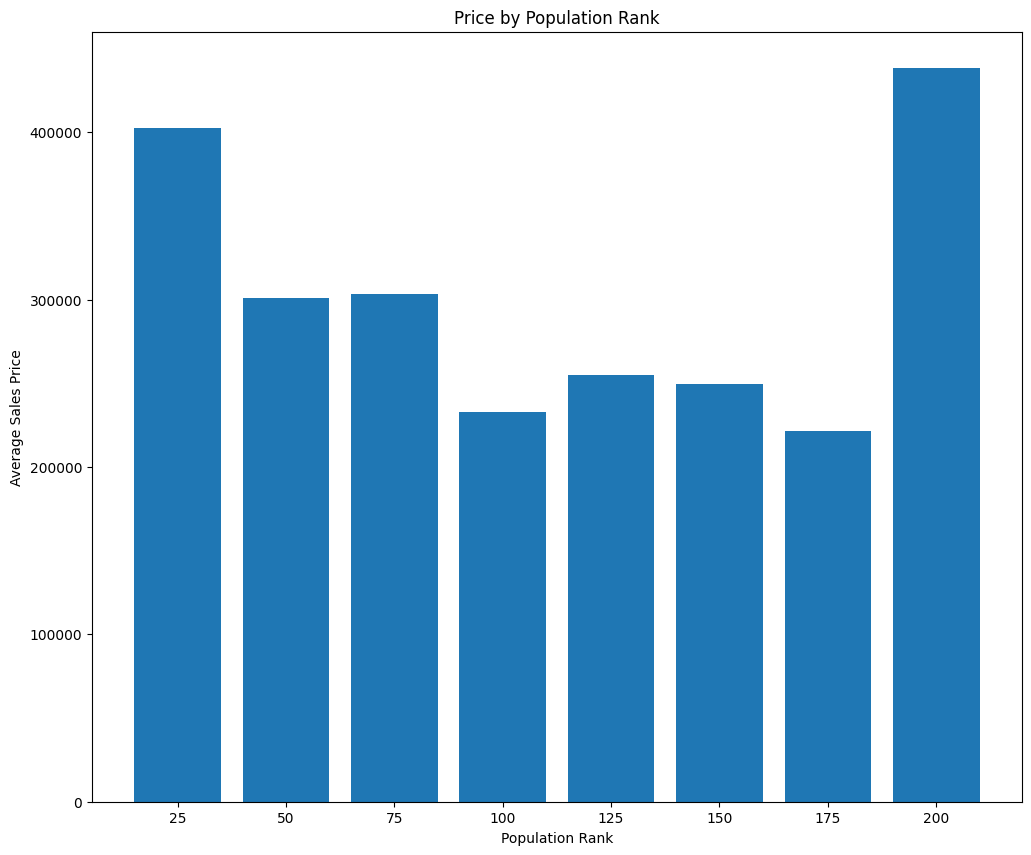

In [92]:
#replot pop_rank_mean without Sante Fe data
pop_rank_mean = pop_rank_mean[pop_rank_mean.pop_rank <= 200]

fig, ax = plt.subplots(figsize=(12, 10))
plt.bar(pop_rank_mean.index, pop_rank_mean.mean_sales_price)
plt.xlabel('Population Rank')
plt.ylabel('Average Sales Price')
plt.title('Price by Population Rank')
plt.show()

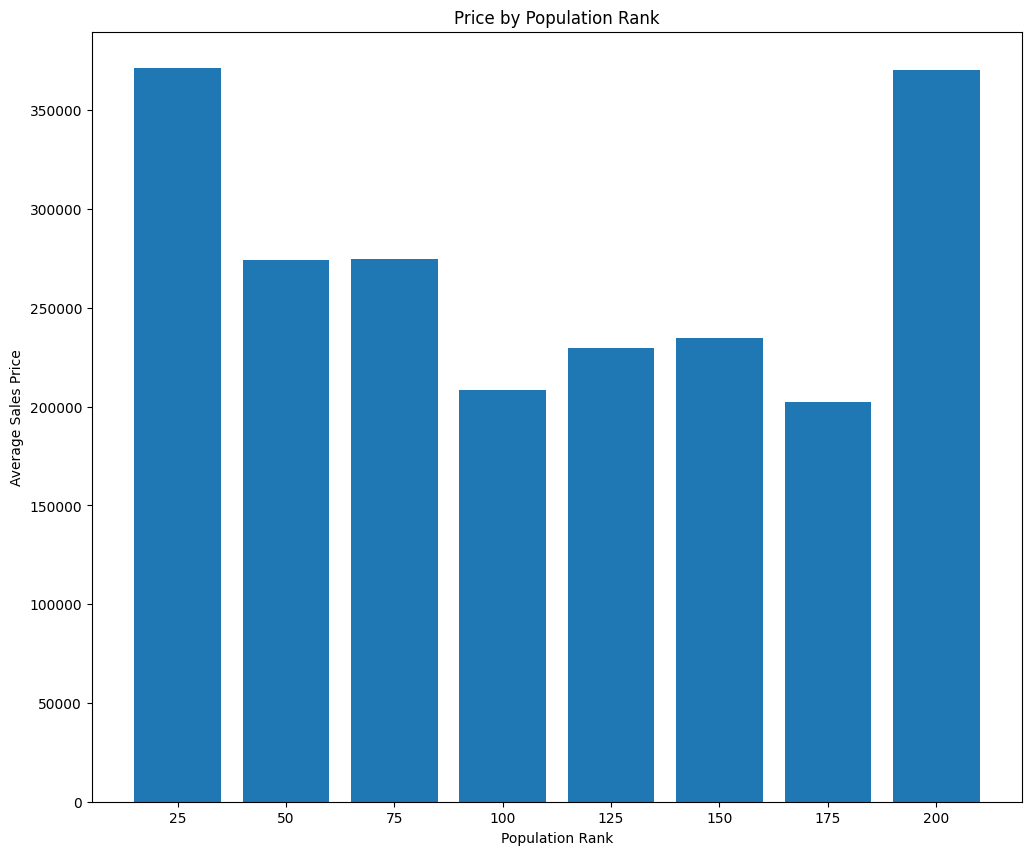

In [93]:
pop_rank_median = pop_rank_median[pop_rank_median.pop_rank <= 200]

fig, ax = plt.subplots(figsize=(12, 10))
plt.bar(pop_rank_median.index, pop_rank_median.mean_sales_price)
plt.xlabel('Population Rank')
plt.ylabel('Average Sales Price')
plt.title('Price by Population Rank')
plt.show()

We can see that generally price decreases as population shrinks but some of the smallest cities in our dataset jump up.

Distribution of data

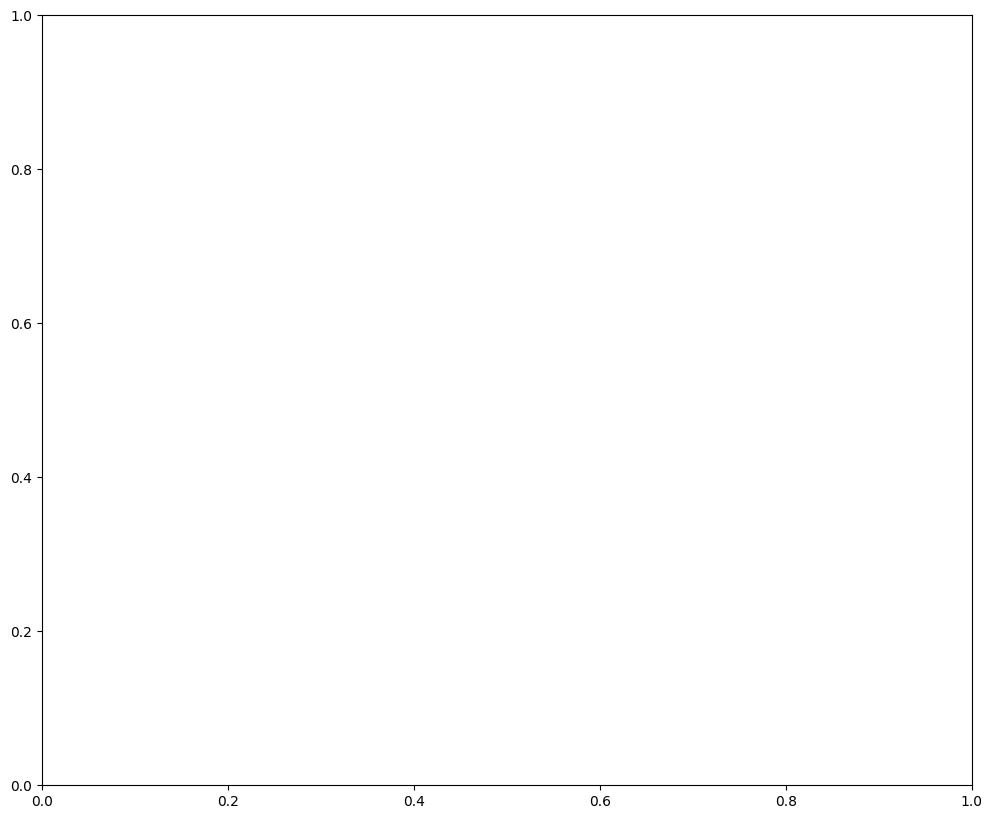

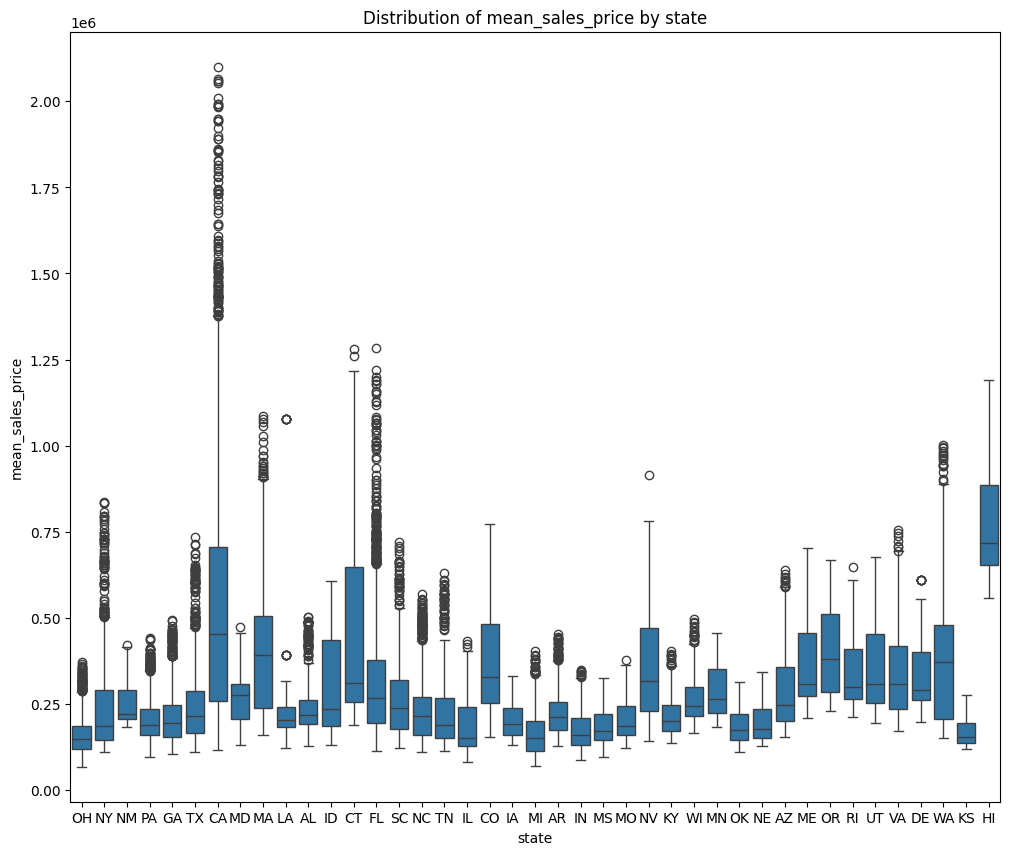

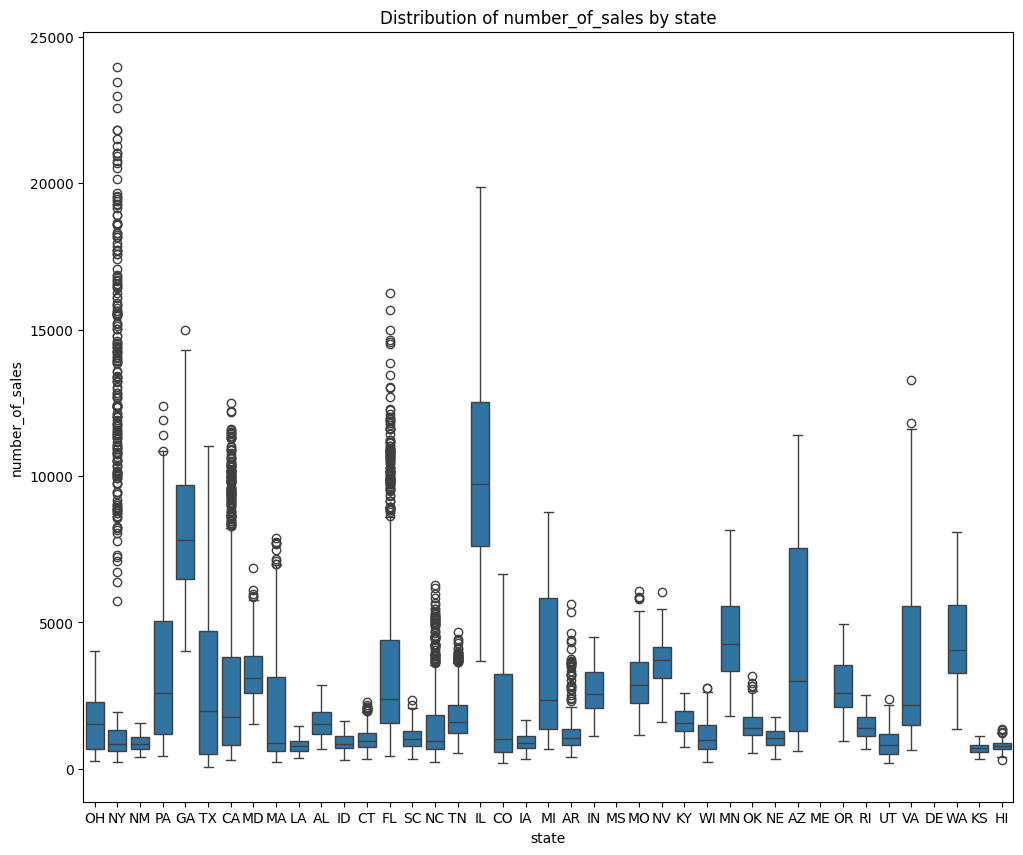

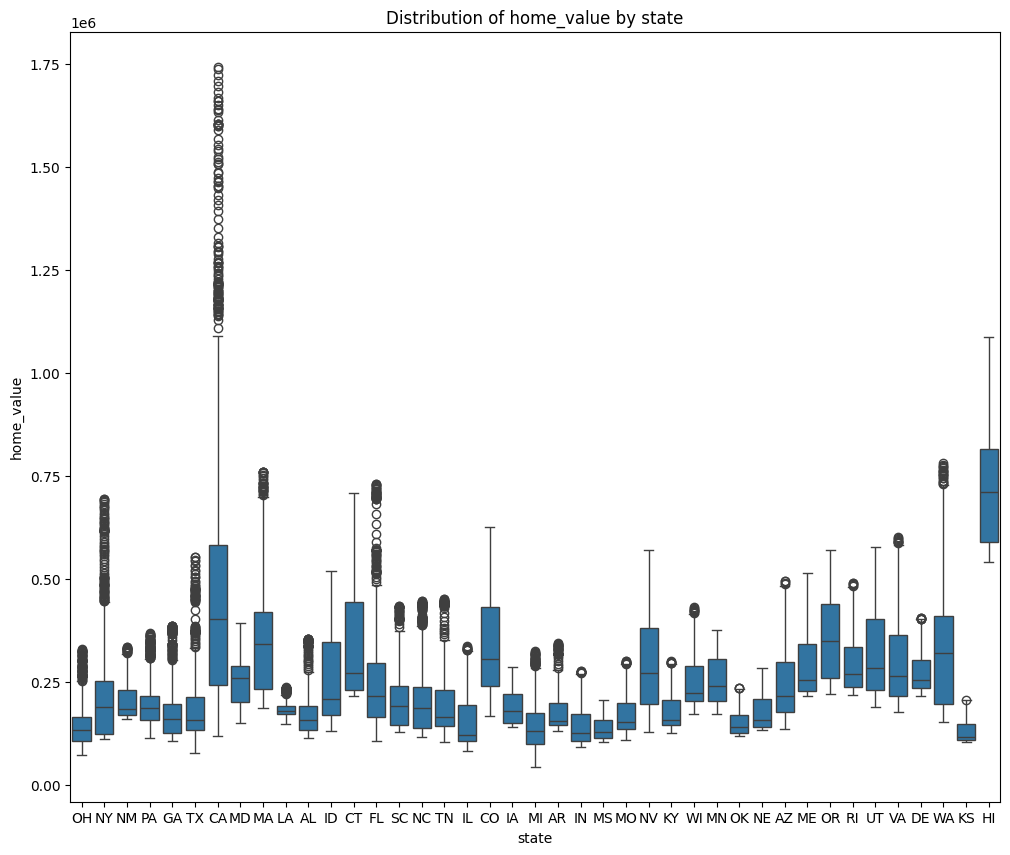

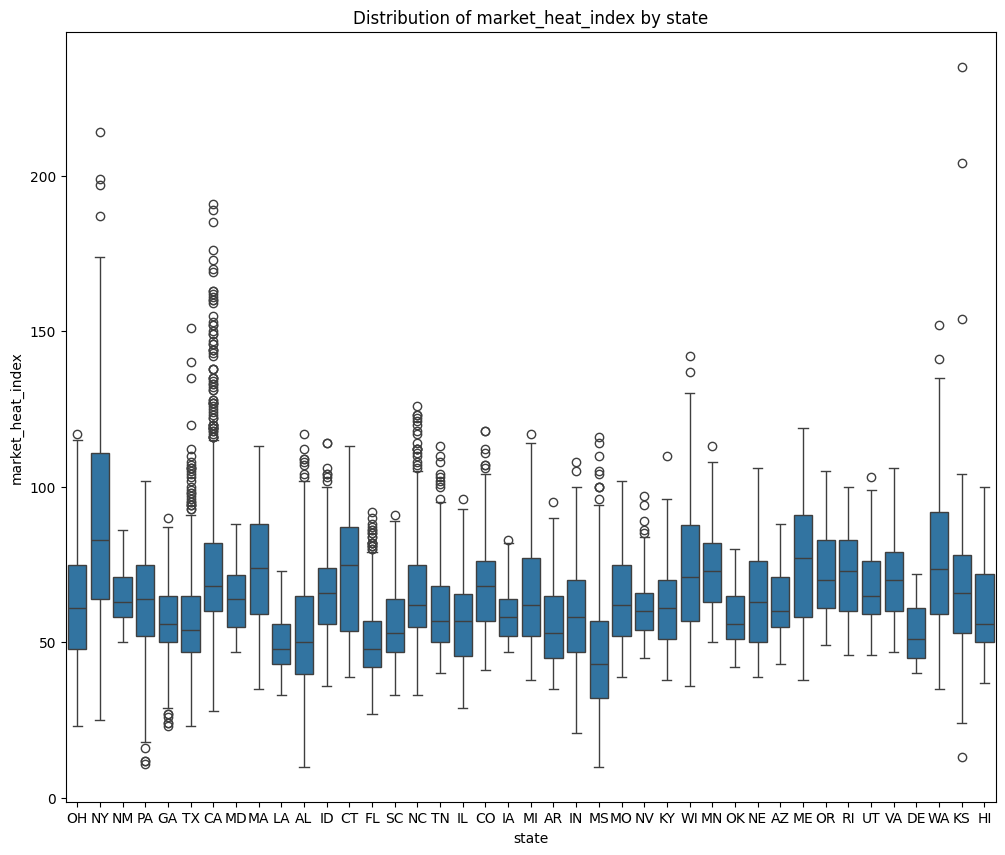

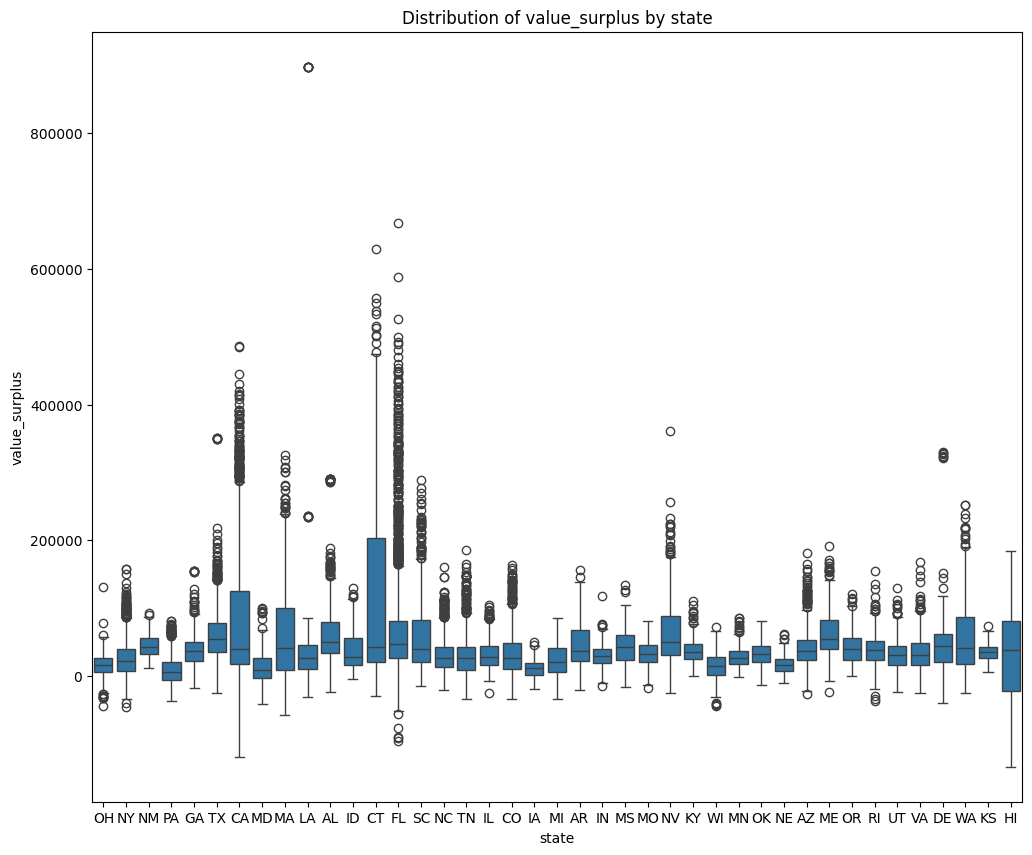

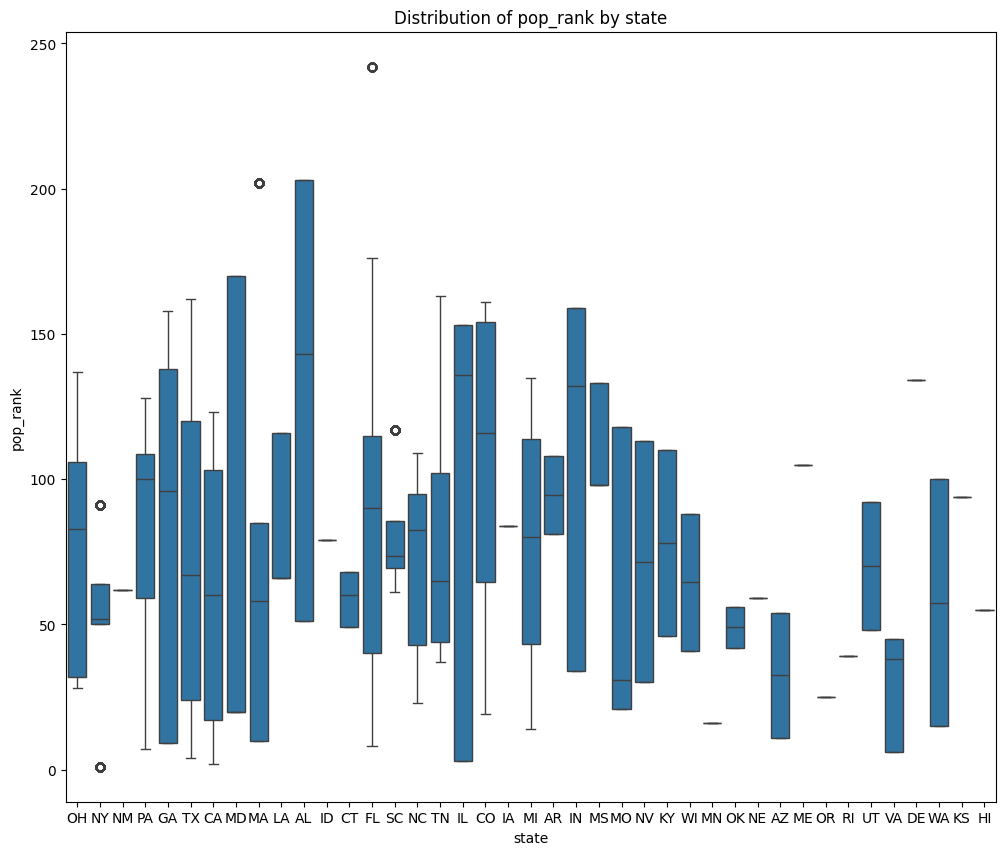

In [94]:
fig, ax = plt.subplots(figsize=(12, 10))
#distribution of data by state
valid_stats_cat = [c for c in stats_cat if c in zillow_df.columns]
for i in valid_stats_cat:
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.boxplot(data=zillow_df, x='state', y=i)
    plt.title(f'Distribution of {i} by state')
    plt.show()


These charts show that while the average sales price and home values don't vary extremely, there are a lot of outliers for certain states (specifically NY and CA). Number of sales varies the most by state and still has a lot of outliers in NY, CA, and FL

In [95]:
#ECDF function
def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(x)+1) / len(x)
    return x, y

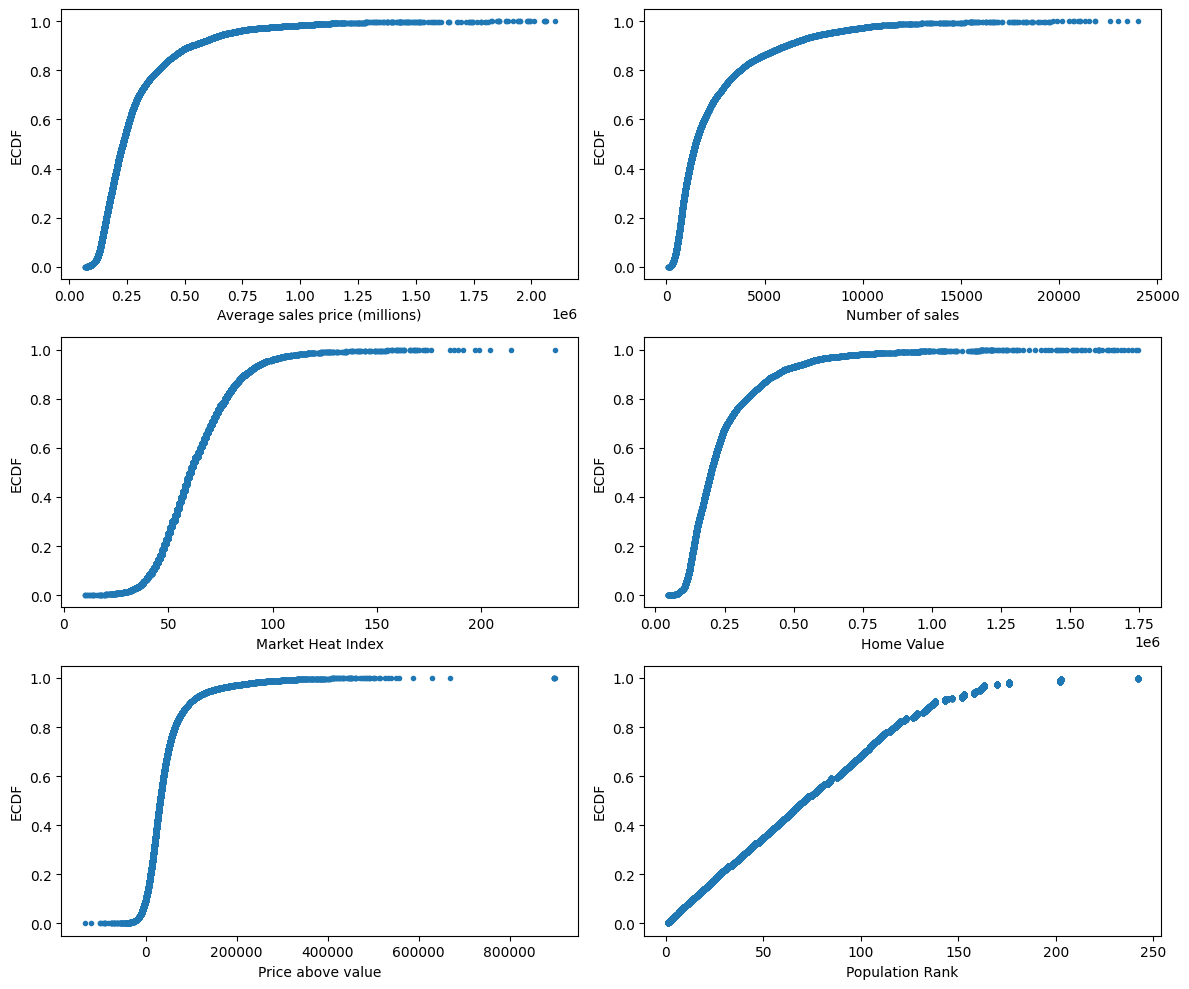

<Figure size 640x480 with 0 Axes>

In [96]:
# ensure value_surplus exists
if 'value_surplus' not in zillow_df.columns:
    zillow_df['value_surplus'] = zillow_df['mean_sales_price'] - zillow_df['home_value']

fig, ax = plt.subplots(3, 2, figsize=(12, 10))
x, y = ecdf(zillow_df['mean_sales_price'].dropna())
ax[0, 0].plot(x, y, marker='.', linestyle='none')
ax[0, 0].set_xlabel('Average sales price (millions)')
ax[0, 0].set_ylabel('ECDF')

x, y = ecdf(zillow_df['number_of_sales'].dropna())
ax[0, 1].plot(x, y, marker='.', linestyle='none')
ax[0, 1].set_xlabel('Number of sales')
ax[0, 1].set_ylabel('ECDF')

x, y = ecdf(zillow_df['home_value'].dropna())
ax[1, 1].plot(x, y, marker='.', linestyle='none')
ax[1, 1].set_xlabel('Home Value')
ax[1, 1].set_ylabel('ECDF')

x, y = ecdf(zillow_df['market_heat_index'].dropna())
ax[1, 0].plot(x, y, marker='.', linestyle='none')
ax[1, 0].set_xlabel('Market Heat Index')
ax[1, 0].set_ylabel('ECDF')

x, y = ecdf(zillow_df['value_surplus'].dropna())
ax[2, 0].plot(x, y, marker='.', linestyle='none')
ax[2, 0].set_xlabel('Price above value')
ax[2, 0].set_ylabel('ECDF')

x, y = ecdf(zillow_df['pop_rank'].dropna())
ax[2, 1].plot(x, y, marker='.', linestyle='none')
ax[2, 1].set_xlabel('Population Rank')
ax[2, 1].set_ylabel('ECDF')

plt.tight_layout()
plt.show()
ax[2, 0].plot(x, y, marker = '.', linestyle = 'none')
ax[2, 0].set_xlabel('Price above value')
ax[2, 0].set_ylabel('ECDF')

x, y = ecdf(zillow_df['pop_rank'])
ax[2, 1].plot(x, y, marker = '.', linestyle = 'none')
ax[2, 1].set_xlabel('Population Rank')
ax[2, 1].set_ylabel('ECDF')

plt.tight_layout()
plt.show()

Generally the distribution of our results doesn't vary much within the first 80-90% of ournumerical data then stretches a lot in the last 10-20% of our dataset. Population rank is more constant which is to be expected since it is a ranking.

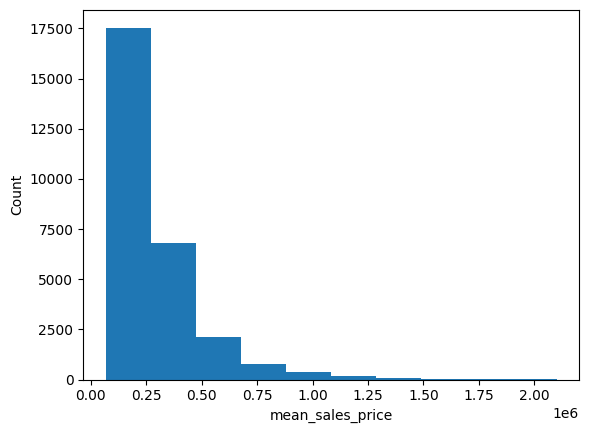

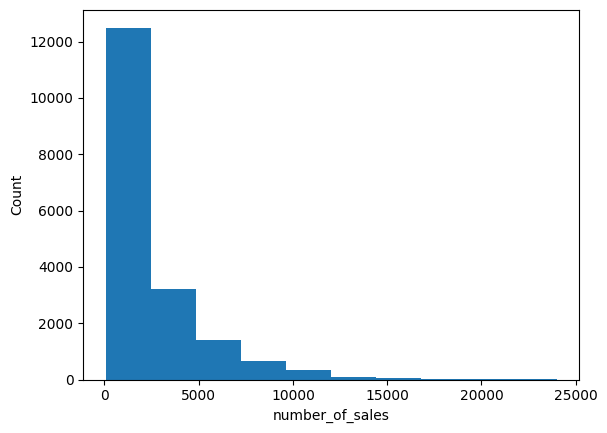

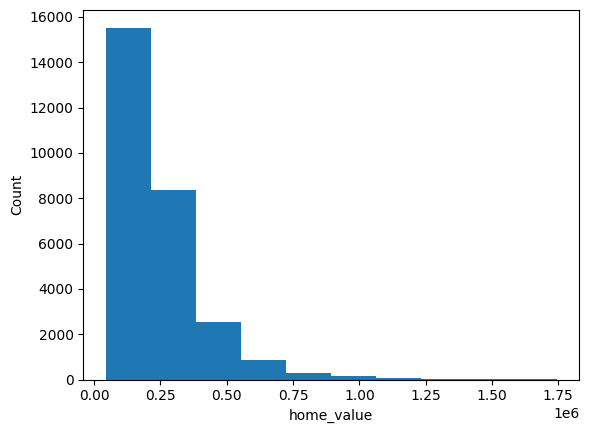

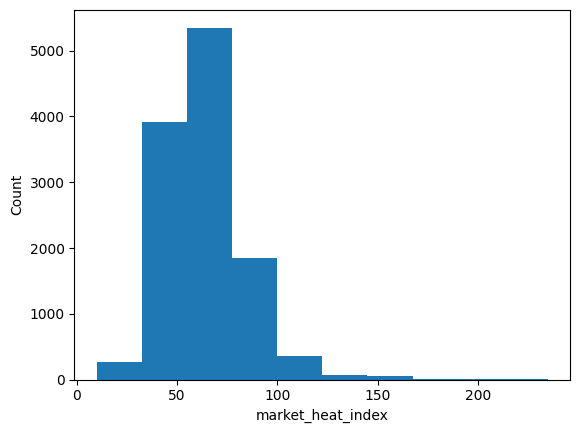

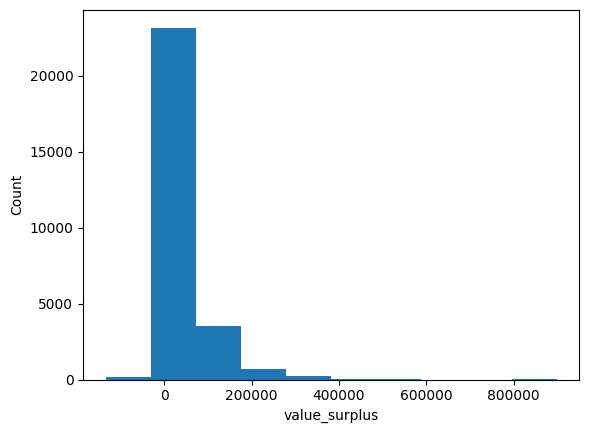

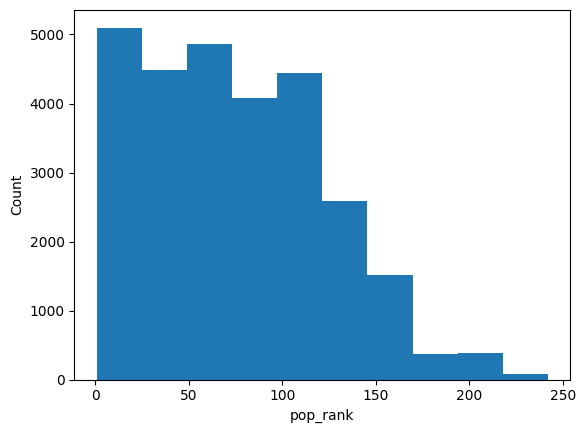

In [97]:
#histogram of data
for i in stats_cat:
    plt.hist(zillow_df[i], bins=10)
    plt.xlabel(i)
    plt.ylabel('Count')
    plt.show()

Most of our data is skewed to the left. When using models it will be important to normalize the data to create a normal distribution

Correlation

In [98]:
#non object/id columns for correlation 
#non object/id columns for correlation 
numeric_data = zillow_df.select_dtypes(include=[np.number]).copy()
# drop identifier-like cols if present
drop_ids = [c for c in ['RegionID', 'SizeRank', 'city', 'state'] if c in numeric_data.columns]
if drop_ids:
    numeric_data = numeric_data.drop(columns=drop_ids)

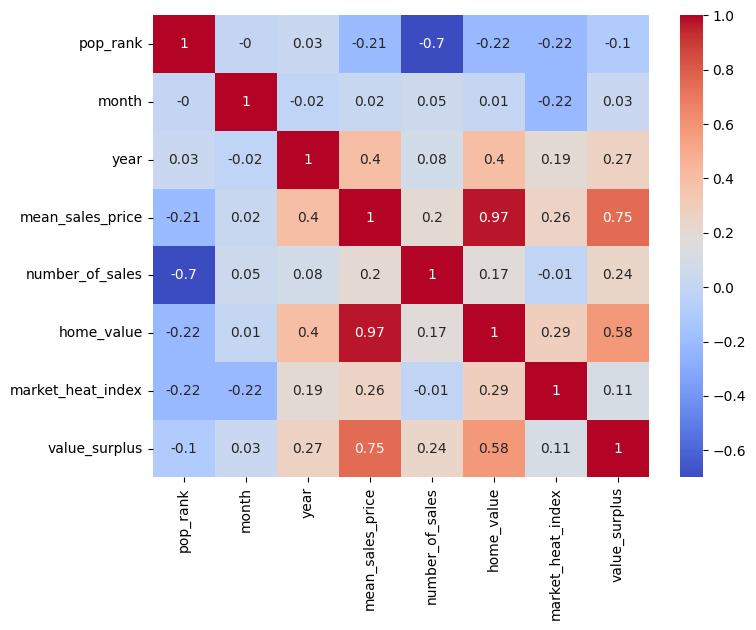

In [99]:
#correlation heatmap
corrmap = numeric_data.corr()
plt.subplots(figsize=(8,6))
sns.heatmap(round(corrmap, 2), annot=True, cmap='coolwarm');

There is a strong correlation between home value and sales price which is expected. The other values positively correlated to our target variable of sales price are value surplue, year, and market heat index. Showing how sales price is related to the year and how much of a buyers/sellers market it is.

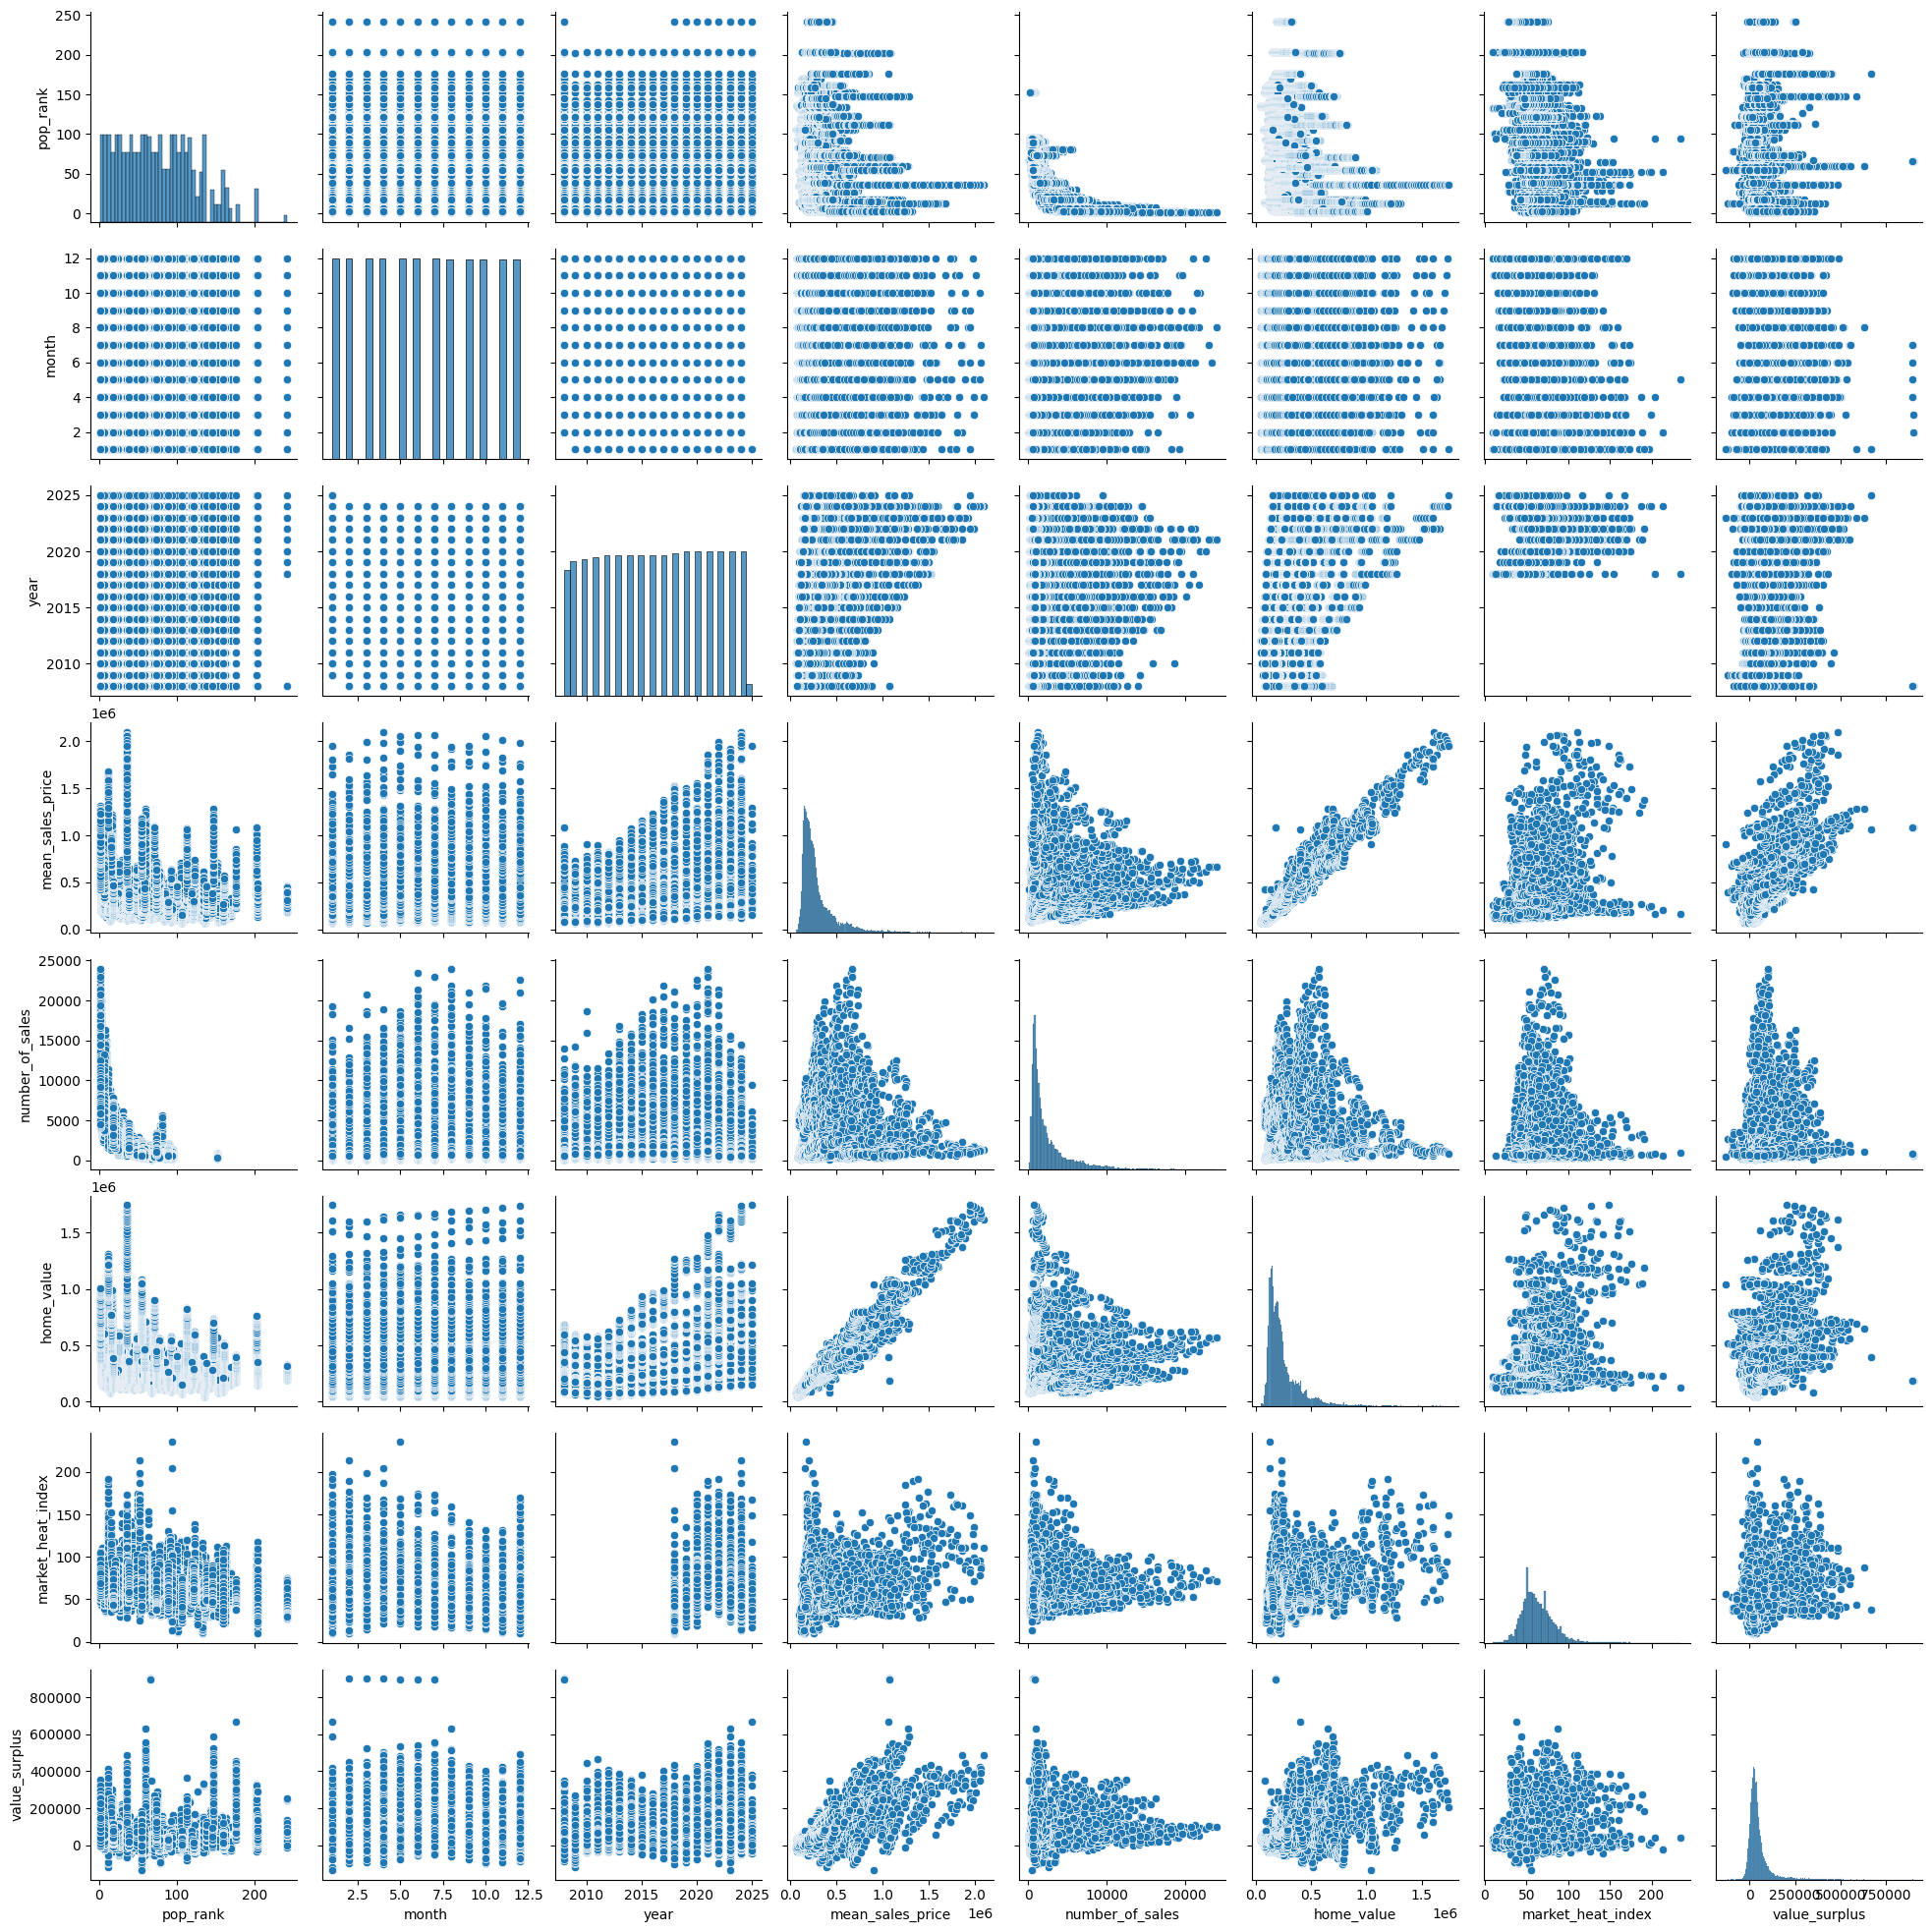

In [100]:
#plots of correlated data
sns.pairplot(numeric_data)
plt.show()

Multivariate plots

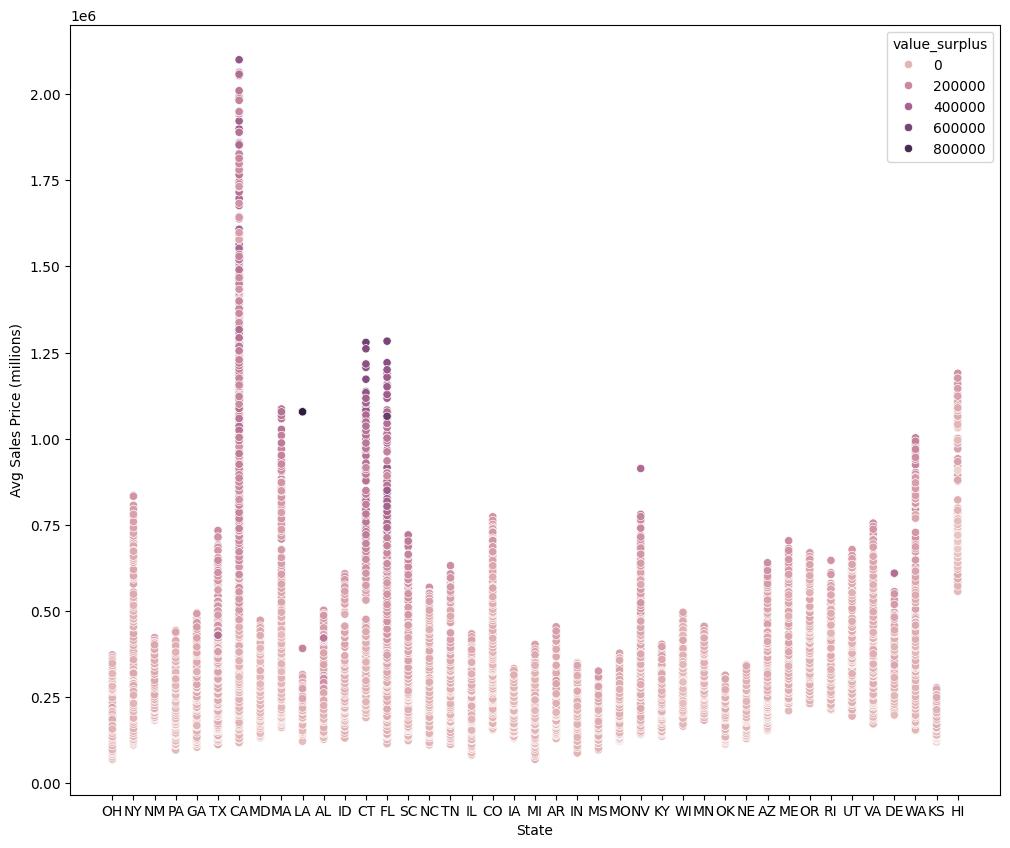

In [101]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.scatterplot(data = zillow_df, x='state', y='mean_sales_price', hue='value_surplus')
plt.xlabel('State')
plt.ylabel('Avg Sales Price (millions)')
plt.show()

This chart shows how for the most part, the highest sales prices correlate with the largest difference from the home value.

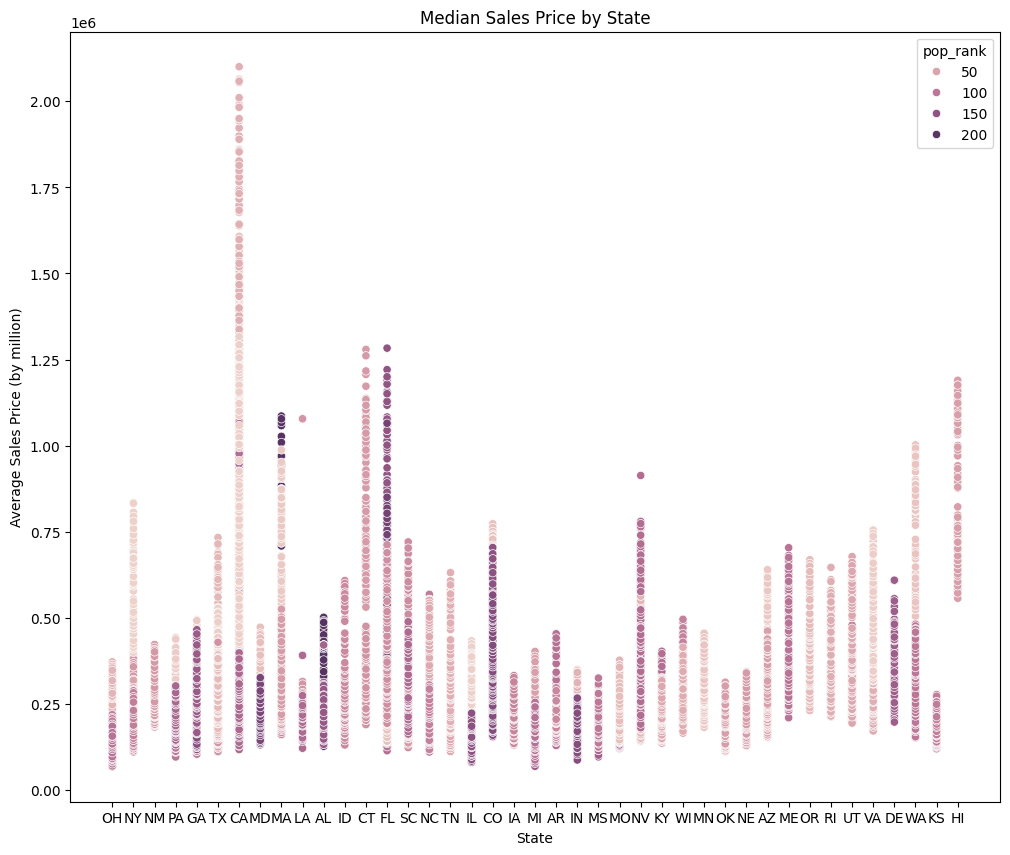

In [102]:
#state median accounting for population size
fig, ax = plt.subplots(figsize=(12, 10))
sns.scatterplot(data=zillow_df, x='state', y='mean_sales_price', hue='pop_rank')
plt.xlabel('State')
plt.ylabel('Average Sales Price (by million)')
plt.title('Median Sales Price by State')
plt.show()

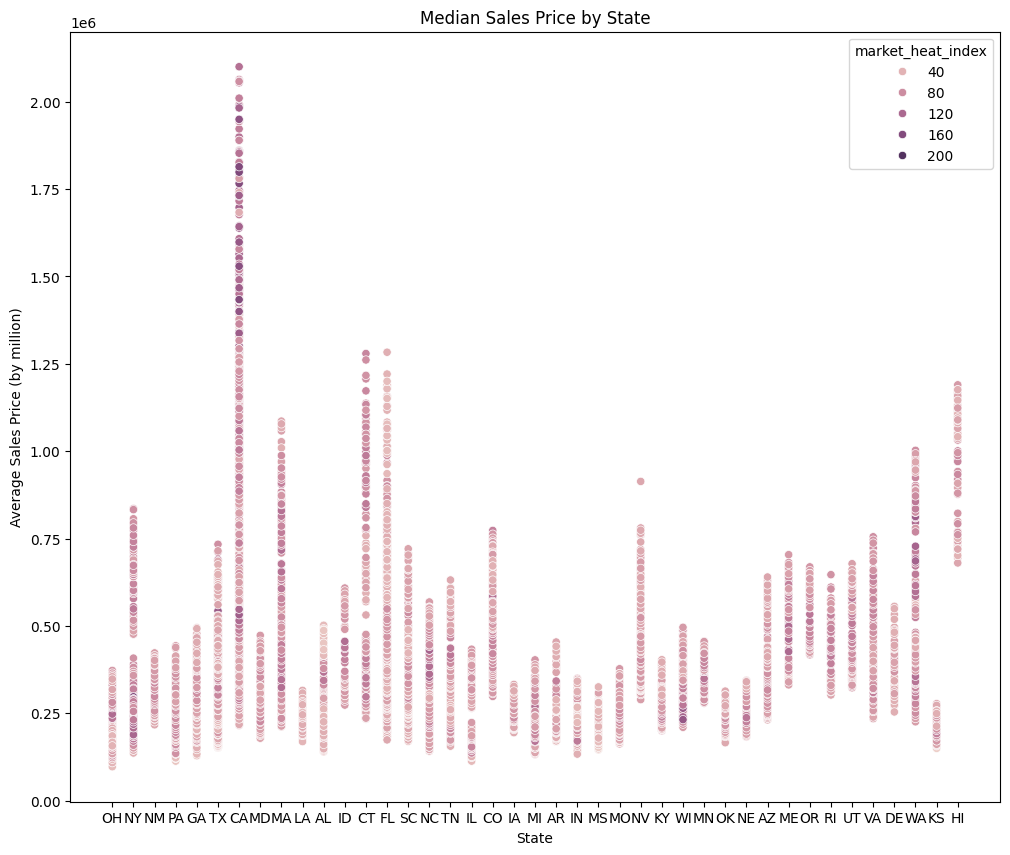

In [103]:
#state median accounting for population size
fig, ax = plt.subplots(figsize=(12, 10))
sns.scatterplot(data=zillow_df, x='state', y='mean_sales_price', hue='market_heat_index')
plt.xlabel('State')
plt.ylabel('Average Sales Price (by million)')
plt.title('Median Sales Price by State')
plt.show()

This chart shows the relationship between population size and sales price. We can see that it varies by state where some states have larger cities with higher prices (TX, NC, PA, NY, IN, IL, WA) and other states have lower prices for larger cities(FL, OR, MA)

In [104]:
#order state medians by year for time plotting
state_medians = state_medians.sort_values('year')
state_medians.head()

,state,year,mean_sales_price,number_of_sales,home_value,market_heat_index,value_surplus,pop_rank
37,DE,2008,609340.00,NaN,283543.16,NaN,325796.84,134.0
674,NE,2008,145345.25,768.0,142275.38,NaN,3837.39,59.0
650,MO,2008,153929.25,2472.0,147499.22,NaN,12460.31,31.0
624,IA,2008,162085.75,751.0,152410.21,NaN,9748.74,84.0
349,MN,2008,249142.80,3263.0,226176.05,NaN,16816.76,16.0


In [105]:
pip install nbformat jupyter ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [106]:
#create map with state data for mean sales
fig = px.choropleth(state_medians, 
                    locations='state', 
                    locationmode='USA-states', 
                    color='mean_sales_price', 
                    color_continuous_scale='reds',
                    range_color=(0, 1000000),
                    animation_frame='year', 
                    scope='usa',
                    title='Avg Sales Price with Time Slider',
                   width=1000,
                   height=800)
fig.show()

The map shows the gradual increase over time for each state. We can see the highest increase in price over the past few years is occuring more in the western states - CA, NV, AZ, UT, CO, NM, WA, OR, ID

In [107]:
fig = px.choropleth(state_medians, 
                    locations='state', 
                    locationmode='USA-states', 
                    color='home_value', 
                    color_continuous_scale='reds',
                    range_color=(0, 1000000),
                    animation_frame='year', 
                    scope='usa',
                    title='Avg Home Value with Time Slider',
                   width=1000,
                   height=800)
fig.show()

As expected from our correlation of home values to sales price, this has similar increases in the same states as sales price

In [108]:
# ensure value_surplus exists in state_medians
if 'value_surplus' not in state_medians.columns:
    state_medians['value_surplus'] = state_medians['mean_sales_price'] - state_medians['home_value']

fig = px.choropleth(state_medians, 
                    locations='state', 
                    locationmode='USA-states', 
                    color='value_surplus', 
                    color_continuous_scale='rdbu_r',
                    color_continuous_midpoint=0,
                    range_color=(-200000, 200000),
                    animation_frame='year', 
                    scope='usa',
                    title='Price over value with Time Slider',
                   width=1000,
                   height=800)
fig.show()

This shows us that the sales price over value was calm for a long time but has spike much more in recent years as the map gets a lot more darker red shades in states such as ME, TX, NV, MA, AZ, NM, MS. Years before 2020 only had 1-2 states that were getting sales prices much higher than asking.

In [109]:
fig = px.choropleth(state_medians, 
                    locations='state', 
                    locationmode='USA-states', 
                    color='number_of_sales', 
                    color_continuous_scale='reds',
                    animation_frame='year', 
                    scope='usa',
                    title='Number of sales with Time Slider',
                   width=1000,
                   height=800)
fig.show()

The number of sales has remained pretty constant in each state where IL and GA having the most in most years.